# 03 — Linear Baseline Model

## Deep Learning in Asset Pricing — Replication Project

This notebook begins the modeling stage of the replication.

The raw data preparation, cleaning, date alignment, and chronological train/validation/test split were already completed in **Notebook 1 — Data Preparation**.

The exploratory analysis and data-quality checks were completed in **Notebook 2 — Exploratory Analysis**.

Therefore, this notebook does **not** reload or reprocess the original raw files `RetChar.csv` and `Macro.csv`.

Instead, it directly loads the processed Parquet files created in Notebook 1:

### Stock-characteristic data

- `retchar_train.parquet`
- `retchar_validation.parquet`
- `retchar_test.parquet`

### Macroeconomic data

- `macro_train.parquet`
- `macro_validation.parquet`
- `macro_test.parquet`

The fixed chronological sample is:

- **Training:** January 1967 – December 1986
- **Validation:** January 1987 – December 1991
- **Test:** January 1992 – December 2016

The stock-characteristic panel contains **46 firm characteristics** together with monthly stock returns.

The macroeconomic panel contains **178 macroeconomic predictors**.

For the first linear asset-pricing benchmark, the primary inputs are the firm characteristics and stock returns. The macroeconomic predictors will become more important in the later nonlinear models, especially when we introduce the macro-state and LSTM components.

---

## Notebook Workflow

The replication workflow is organized as follows:

**Notebook 1 — Data Preparation**

Prepare the original stock and macroeconomic datasets, verify the sample, and save fixed train, validation, and test datasets.

**Notebook 2 — Exploratory Analysis**

Study return distributions, firm-characteristic behavior, correlations, macroeconomic predictors, sample alignment, and other data diagnostics.

**Notebook 3 — Linear Baseline**

Load the already-processed data and estimate a transparent linear asset-pricing benchmark before moving to more complex nonlinear models.

The purpose of the linear benchmark is to provide a simple reference model against which the later feedforward neural-network, LSTM, and adversarial asset-pricing models can be compared.

Throughout this notebook, the training sample is used for model estimation, the validation sample is used for model selection or regularization decisions, and the test sample is reserved for final out-of-sample evaluation.

This separation is maintained to avoid look-ahead bias and data leakage.

## 1. Imports and Reproducibility

We load the numerical, data-management, plotting, and regularized-regression libraries used in this notebook. A fixed seed keeps later tuning steps reproducible.

In [2]:
from pathlib import Path
from io import BytesIO
import re
import urllib.request
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

print("NumPy :", np.__version__)
print("pandas:", pd.__version__)

NumPy : 2.5.3
pandas: 3.0.5


## 2. Locate the Repository Root and Define Project Paths

This section identifies the root directory of the replication project and defines the folders used throughout the notebook.

Because the notebook may be launched from different working directories, the `find_repo_root()` function searches upward until it finds a directory containing both the `data/` and `notebooks/` folders.

Once the repository root is identified, we define paths for:

- `data/processed/` — processed train, validation, and test datasets created in Notebook 1,
- `data/external/` — external data that may be required later,
- `results/tables/` — model-performance and diagnostic tables,
- `results/models/` — estimated model coefficients,
- `results/factors/` — estimated SDF factor returns.

The result directories are created automatically if they do not already exist.

No stock or macroeconomic data are loaded in this section.

In [3]:
def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing data/ and notebooks/.")

ROOT = find_repo_root()
PROCESSED_DIR = ROOT / "data" / "processed"
EXTERNAL_DIR = ROOT / "data" / "external"
RESULTS_DIR = ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
MODELS_DIR = RESULTS_DIR / "models"
FACTORS_DIR = RESULTS_DIR / "factors"

for directory in [EXTERNAL_DIR, TABLES_DIR, MODELS_DIR, FACTORS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Repository root:", ROOT)
print("Processed data :", PROCESSED_DIR)
print("Results        :", RESULTS_DIR)

Repository root: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project
Processed data : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/data/processed
Results        : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results


## 3. Configuration and Load the Processed Data

The data preparation and chronological sample split were completed in Notebook 1.

Therefore, this notebook directly loads the processed stock-characteristic and macroeconomic datasets rather than returning to the original raw CSV files.

The sample is divided into three fixed periods:

- **Training:** January 1967 – December 1986
- **Validation:** January 1987 – December 1991
- **Test:** January 1992 – December 2016

The training sample will be used to estimate the linear asset-pricing model. The validation sample will be used for model-selection and regularization decisions, while the test sample will be reserved for final out-of-sample evaluation.

Keeping these periods separate is important for preventing look-ahead bias.

The processed stock dataset contains monthly stock returns and 46 firm characteristics. The processed macroeconomic dataset contains 178 macroeconomic predictors.

Although the macroeconomic data are loaded here for consistency with the overall replication pipeline, the first linear benchmark primarily uses the stock-characteristic panel. The macroeconomic predictors will become more important in later nonlinear specifications.

In [4]:
# 3. Configuration and load processed data

DATE_COL = "date"
RETURN_COL = "ret"

# --------------------------------------------------
# File locations
# --------------------------------------------------

stock_files = {
    "train": PROCESSED_DIR / "retchar_train.parquet",
    "validation": PROCESSED_DIR / "retchar_validation.parquet",
    "test": PROCESSED_DIR / "retchar_test.parquet",
}

macro_files = {
    "train": PROCESSED_DIR / "macro_train.parquet",
    "validation": PROCESSED_DIR / "macro_validation.parquet",
    "test": PROCESSED_DIR / "macro_test.parquet",
}


# --------------------------------------------------
# Verify that all required files exist
# --------------------------------------------------

all_files = list(stock_files.values()) + list(macro_files.values())

missing_files = [
    path for path in all_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Missing processed files:\n"
        + "\n".join(str(path) for path in missing_files)
    )


# --------------------------------------------------
# Load stock-characteristic data
# --------------------------------------------------

stock_train = pd.read_parquet(
    stock_files["train"]
)

stock_valid = pd.read_parquet(
    stock_files["validation"]
)

stock_test = pd.read_parquet(
    stock_files["test"]
)


# --------------------------------------------------
# Load macroeconomic data
# --------------------------------------------------

macro_train = pd.read_parquet(
    macro_files["train"]
)

macro_valid = pd.read_parquet(
    macro_files["validation"]
)

macro_test = pd.read_parquet(
    macro_files["test"]
)


# --------------------------------------------------
# Display dimensions
# --------------------------------------------------

print("STOCK DATA")
print("-" * 50)

print(
    "Training   :",
    stock_train.shape
)

print(
    "Validation :",
    stock_valid.shape
)

print(
    "Test       :",
    stock_test.shape
)


print("\nMACRO DATA")
print("-" * 50)

print(
    "Training   :",
    macro_train.shape
)

print(
    "Validation :",
    macro_valid.shape
)

print(
    "Test       :",
    macro_test.shape
)

STOCK DATA
--------------------------------------------------
Training   : (336113, 48)
Validation : (132167, 48)
Test       : (750275, 48)

MACRO DATA
--------------------------------------------------
Training   : (240, 179)
Validation : (60, 179)
Test       : (300, 179)


In [73]:
print(
    stock_train[
        [DATE_COL, RETURN_COL]
    ].head(20)
)

print(
    "\nFirst date:",
    stock_train[DATE_COL].min()
)

print(
    "Last date:",
    stock_train[DATE_COL].max()
)

         date       ret
0  1967-01-01  0.136223
1  1967-01-01  0.317129
2  1967-01-01  0.101064
3  1967-01-01  0.287367
4  1967-01-01  0.143427
5  1967-01-01  0.162367
6  1967-01-01  0.157643
7  1967-01-01 -0.081223
8  1967-01-01 -0.000577
9  1967-01-01  0.415700
10 1967-01-01  0.118581
11 1967-01-01  0.009033
12 1967-01-01  0.047973
13 1967-01-01  0.133266
14 1967-01-01  0.140861
15 1967-01-01  0.151950
16 1967-01-01 -0.004300
17 1967-01-01 -0.013915
18 1967-01-01 -0.007182
19 1967-01-01  0.125570

First date: 1967-01-01 00:00:00
Last date: 1986-12-01 00:00:00


## 4. Load the Processed Stock Splits

We load the exact Parquet files written by Notebook 01 rather than recreating the split.

Using the saved training, validation, and test files ensures that the modeling sample remains identical to the sample constructed during the data-preparation stage.

The three stock datasets correspond to:

- Training: January 1967 – December 1986
- Validation: January 1987 – December 1991
- Test: January 1992 – December 2016

The date column is converted to a consistent monthly timestamp format before model estimation.

At this stage, we only load the processed stock-characteristic panel. No additional cleaning, normalization, or sample splitting is performed.

In [41]:
# 4. Load the Processed Stock Splits

missing = [
    str(p)
    for p in stock_files.values()
    if not p.exists()
]

if missing:
    raise FileNotFoundError(
        "Missing required processed file(s):\n"
        + "\n".join(missing)
    )


stock_train = pd.read_parquet(
    stock_files["train"]
)

stock_valid = pd.read_parquet(
    stock_files["validation"]
)

stock_test = pd.read_parquet(
    stock_files["test"]
)


for df in [
    stock_train,
    stock_valid,
    stock_test
]:
    df[DATE_COL] = (
        pd.to_datetime(df[DATE_COL])
        .dt.to_period("M")
        .dt.to_timestamp()
    )


print("Train     :", stock_train.shape)
print("Validation:", stock_valid.shape)
print("Test      :", stock_test.shape)

Train     : (336113, 48)
Validation: (132167, 48)
Test      : (750275, 48)


## 5. Verify the Modeling Sample and Identify the 46 Characteristics

Before estimating the linear model, we verify that the processed stock panel has the expected structure.

The date and return columns are excluded from the predictor set, leaving the **46 firm characteristics** used in the replication.

Because the preprocessing was already completed in Notebook 1, we expect:

- exactly 46 firm characteristics,
- no missing stock returns,
- no missing characteristic values,
- the correct train, validation, and test date ranges.

This step ensures that the modeling stage uses exactly the same information set constructed during data preparation and that no observations were accidentally lost or altered before estimation.

In [7]:
# 5. Verify modeling sample and identify the 46 characteristics

characteristic_cols = [
    c for c in stock_train.columns
    if c not in [DATE_COL, RETURN_COL]
]

print(
    "Number of firm characteristics:",
    len(characteristic_cols)
)

assert len(characteristic_cols) == 46, (
    f"Expected 46 characteristics, "
    f"but found {len(characteristic_cols)}."
)


def summarize_split(name, df):

    return {
        "sample": name,
        "observations": len(df),
        "months": df[DATE_COL].nunique(),
        "start_date": df[DATE_COL].min(),
        "end_date": df[DATE_COL].max(),
        "missing_returns":
            int(df[RETURN_COL].isna().sum()),
        "missing_characteristics":
            int(
                df[characteristic_cols]
                .isna()
                .sum()
                .sum()
            ),
    }


sample_summary = pd.DataFrame([
    summarize_split(
        "Training",
        stock_train
    ),
    summarize_split(
        "Validation",
        stock_valid
    ),
    summarize_split(
        "Test",
        stock_test
    ),
])

display(sample_summary)


print("\nFirm characteristics:")
print(characteristic_cols)

Number of firm characteristics: 46


,sample,observations,months,start_date,end_date,missing_returns,missing_characteristics
0,Training,336113,240,1967-01-01,1986-12-01,0,0
1,Validation,132167,60,1987-01-01,1991-12-01,0,0
2,Test,750275,300,1992-01-01,2016-12-01,0,0



Firm characteristics:
['a2me', 'ac', 'at', 'ato', 'beme', 'beta', 'c', 'cf', 'cf2p', 'cto', 'd2a', 'd2p', 'dpi2a', 'e2p', 'fc2y', 'idiovol', 'investment', 'lev', 'lme', 'lt_rev', 'lturnover', 'mktbeta', 'ni', 'noa', 'oa', 'ol', 'op', 'pcm', 'pm', 'prof', 'q', 'r2_1', 'r12_2', 'r12_7', 'r36_13', 'rel2high', 'resid_var', 'rna', 'roa', 'roe', 's2p', 'sga2s', 'spread', 'st_rev', 'suv', 'variance']


In [36]:
# check for 4 and 5 
# ==================================================
# AUDIT: Parts 4 and 5
# ==================================================

print("=" * 70)
print("1. STOCK DATA SHAPES")
print("=" * 70)

print("Train      :", stock_train.shape)
print("Validation :", stock_valid.shape)
print("Test       :", stock_test.shape)


print("\n" + "=" * 70)
print("2. DATE RANGES")
print("=" * 70)

for name, df in [
    ("Train", stock_train),
    ("Validation", stock_valid),
    ("Test", stock_test),
]:
    print(
        f"{name:10s}: "
        f"{df[DATE_COL].min()} -> "
        f"{df[DATE_COL].max()} | "
        f"{df[DATE_COL].nunique()} months"
    )


print("\n" + "=" * 70)
print("3. COLUMNS")
print("=" * 70)

print(stock_train.columns.tolist())


print("\n" + "=" * 70)
print("4. CHARACTERISTIC COUNT")
print("=" * 70)

characteristic_cols_check = [
    c for c in stock_train.columns
    if c not in [
        DATE_COL,
        RETURN_COL,
        "rf",
        "ret_excess"
    ]
]

print(
    "Number of characteristics:",
    len(characteristic_cols_check)
)

print(characteristic_cols_check)


print("\n" + "=" * 70)
print("5. MISSING VALUES")
print("=" * 70)

for name, df in [
    ("Train", stock_train),
    ("Validation", stock_valid),
    ("Test", stock_test),
]:

    missing_ret = (
        df[RETURN_COL]
        .isna()
        .sum()
    )

    missing_char = (
        df[
            characteristic_cols_check
        ]
        .isna()
        .sum()
        .sum()
    )

    print(
        f"{name:10s}: "
        f"missing returns = {missing_ret}, "
        f"missing characteristics = {missing_char}"
    )


print("\n" + "=" * 70)
print("6. RETURN SUMMARY")
print("=" * 70)

display(
    stock_train[
        RETURN_COL
    ].describe(
        percentiles=[
            0.01,
            0.05,
            0.50,
            0.95,
            0.99
        ]
    )
)


print("\n" + "=" * 70)
print("7. CHARACTERISTIC RANGE CHECK")
print("=" * 70)

char_min = (
    stock_train[
        characteristic_cols_check
    ]
    .min()
    .min()
)

char_max = (
    stock_train[
        characteristic_cols_check
    ]
    .max()
    .max()
)

print(
    "Global characteristic minimum:",
    char_min
)

print(
    "Global characteristic maximum:",
    char_max
)

1. STOCK DATA SHAPES
Train      : (336113, 50)
Validation : (132167, 50)
Test       : (750275, 50)

2. DATE RANGES
Train     : 1967-01-01 00:00:00 -> 1986-12-01 00:00:00 | 240 months
Validation: 1987-01-01 00:00:00 -> 1991-12-01 00:00:00 | 60 months
Test      : 1992-01-01 00:00:00 -> 2016-12-01 00:00:00 | 300 months

3. COLUMNS
['date', 'ret', 'a2me', 'ac', 'at', 'ato', 'beme', 'beta', 'c', 'cf', 'cf2p', 'cto', 'd2a', 'd2p', 'dpi2a', 'e2p', 'fc2y', 'idiovol', 'investment', 'lev', 'lme', 'lt_rev', 'lturnover', 'mktbeta', 'ni', 'noa', 'oa', 'ol', 'op', 'pcm', 'pm', 'prof', 'q', 'r2_1', 'r12_2', 'r12_7', 'r36_13', 'rel2high', 'resid_var', 'rna', 'roa', 'roe', 's2p', 'sga2s', 'spread', 'st_rev', 'suv', 'variance', 'rf', 'ret_excess']

4. CHARACTERISTIC COUNT
Number of characteristics: 46
['a2me', 'ac', 'at', 'ato', 'beme', 'beta', 'c', 'cf', 'cf2p', 'cto', 'd2a', 'd2p', 'dpi2a', 'e2p', 'fc2y', 'idiovol', 'investment', 'lev', 'lme', 'lt_rev', 'lturnover', 'mktbeta', 'ni', 'noa', 'oa', 'ol',

count   336,113.000000
mean          0.007283
std           0.128763
min          -0.855500
1%           -0.273167
5%           -0.172017
50%          -0.004600
95%           0.215922
99%           0.406634
max           5.244800
Name: ret, dtype: float64


7. CHARACTERISTIC RANGE CHECK
Global characteristic minimum: -0.5
Global characteristic maximum: 0.5


## 6. Risk-Free Rate

The asset-pricing models in this replication are estimated using **excess stock returns**, so we need a monthly risk-free rate before constructing the modeling target.

The processed stock dataset created in Notebook 1 contains monthly stock returns, but it does not contain a separate risk-free-rate series. Therefore, this notebook obtains the monthly risk-free rate from the **Kenneth French Data Library**.

We use the monthly Fama–French 5-factor file because it contains a dedicated `RF` column representing the monthly risk-free return.

The raw Fama–French file reports returns in **percent**, so the risk-free rate is converted to decimal form before it is used in later calculations.

For example, 
\[$
0.43\%
=
0.0043.$
\]

To make the notebook reproducible and efficient, the code follows two possible paths:

1. If a previously validated file named

   `data/external/ff_rf_monthly.csv`

   already exists, the notebook loads that cached file directly.

2. If the cached file does not exist, the notebook downloads the Fama–French 5-factor data, identifies the `RF` column by its column name, extracts the monthly observations, converts the values from percent to decimal form, and saves the resulting series locally.

Identifying the `RF` column by name is important because other columns in the Fama–French file, such as `CMA`, are not risk-free returns and should not be used for the excess-return calculation.

Several diagnostic checks are included to verify that:

- the `RF` column is correctly identified,
- the monthly dates are parsed correctly,
- there are no missing or invalid risk-free observations,
- the values are economically plausible,
- the series covers the full period required by the stock data.

As a simple sanity check, the January 1967 risk-free rate should be approximately

\[
R^f_{1967:01}=0.0043,
\]

or 0.43 percent for the month.

In the next section, this monthly risk-free rate will be merged with the stock panel and used to construct excess returns:

\[$
R^e_{i,t}
=
R_{i,t}
-
R^f_t.$
\]

In [39]:
# ==================================================
# 6. Risk-Free Rate
# ==================================================

from io import BytesIO
import urllib.request
import zipfile
import re


RF_CACHE = EXTERNAL_DIR / "ff_rf_monthly.csv"

FF5_URL = (
    "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/"
    "F-F_Research_Data_5_Factors_2x3_CSV.zip"
)


def load_risk_free_rate(
    cache_path=RF_CACHE,
    url=FF5_URL
):
    """
    Load the monthly Fama-French risk-free rate.

    If a previously downloaded and validated file exists,
    use the cached version.

    Otherwise, download the Fama-French 5-factor file,
    identify the RF column by name, convert RF from
    percent to decimal form, and save it locally.
    """

    # --------------------------------------------------
    # 1. Use cached RF data if available
    # --------------------------------------------------

    if cache_path.exists():

        rf = pd.read_csv(
            cache_path,
            parse_dates=["date"]
        )

        # Basic structure check
        required_columns = {"date", "rf"}

        if not required_columns.issubset(
            rf.columns
        ):
            raise ValueError(
                "Cached RF file does not contain "
                "the required columns: date and rf."
            )

        rf["date"] = (
            pd.to_datetime(rf["date"])
            .dt.to_period("M")
            .dt.to_timestamp()
        )

        rf["rf"] = pd.to_numeric(
            rf["rf"],
            errors="coerce"
        )

        if rf["rf"].isna().any():
            raise ValueError(
                "Cached RF file contains missing "
                "or invalid RF observations."
            )

        # Sanity check
        if rf["rf"].abs().max() > 0.03:
            raise ValueError(
                "Cached RF values appear implausibly large. "
                "Delete the cache and download it again."
            )

        rf = (
            rf
            .drop_duplicates(
                subset="date"
            )
            .sort_values("date")
            .reset_index(drop=True)
        )

        print(
            "Loaded cached risk-free data:"
        )
        print(cache_path)

        return rf


    # --------------------------------------------------
    # 2. Download Fama-French 5-factor file
    # --------------------------------------------------

    print(
        "Downloading monthly risk-free rate..."
    )

    with urllib.request.urlopen(
        url,
        timeout=30
    ) as response:

        content = response.read()


    # --------------------------------------------------
    # 3. Read CSV contained inside ZIP
    # --------------------------------------------------

    with zipfile.ZipFile(
        BytesIO(content)
    ) as zf:

        csv_files = [
            name
            for name in zf.namelist()
            if name.lower().endswith(".csv")
        ]

        if not csv_files:
            raise RuntimeError(
                "No CSV file found inside "
                "the downloaded ZIP archive."
            )

        text = (
            zf.read(csv_files[0])
            .decode(
                "utf-8",
                errors="replace"
            )
        )


    # --------------------------------------------------
    # 4. Identify the header dynamically
    # --------------------------------------------------

    lines = text.splitlines()

    header_line = None

    for line in lines:

        if (
            "Mkt-RF" in line
            and "CMA" in line
            and "RF" in line
        ):
            header_line = line
            break


    if header_line is None:
        raise RuntimeError(
            "Could not locate the "
            "Fama-French column header."
        )


    header = [
        x.strip()
        for x in header_line.split(",")
    ]

    print(
        "Detected columns:"
    )
    print(header)


    # Find RF by column NAME,
    # not by a hard-coded position
    if "RF" not in header:
        raise RuntimeError(
            "RF column not found."
        )

    rf_position = header.index(
        "RF"
    )

    print(
        "RF column position:",
        rf_position
    )


    # --------------------------------------------------
    # 5. Extract monthly RF observations
    # --------------------------------------------------

    rows = []

    for line in lines:

        parts = [
            x.strip()
            for x in line.split(",")
        ]

        if len(parts) <= rf_position:
            continue

        # Monthly observations use YYYYMM
        if re.fullmatch(
            r"\d{6}",
            parts[0]
        ):

            try:

                yyyymm = parts[0]

                rf_percent = float(
                    parts[rf_position]
                )

                # French data report RF in percent.
                # Convert to decimal.
                rf_decimal = (
                    rf_percent / 100.0
                )

                rows.append(
                    (
                        yyyymm,
                        rf_decimal
                    )
                )

            except ValueError:
                continue


    if len(rows) == 0:
        raise RuntimeError(
            "No monthly RF observations "
            "could be parsed."
        )


    # --------------------------------------------------
    # 6. Construct clean RF DataFrame
    # --------------------------------------------------

    rf = pd.DataFrame(
        rows,
        columns=[
            "yyyymm",
            "rf"
        ]
    )

    rf["date"] = pd.to_datetime(
        rf["yyyymm"],
        format="%Y%m"
    )

    rf = (
        rf[
            [
                "date",
                "rf"
            ]
        ]
        .drop_duplicates(
            subset="date"
        )
        .sort_values("date")
        .reset_index(drop=True)
    )


    # --------------------------------------------------
    # 7. Sanity checks
    # --------------------------------------------------

    if rf["rf"].isna().any():
        raise ValueError(
            "Missing values detected "
            "in the RF series."
        )


    if rf["rf"].abs().max() > 0.03:
        raise ValueError(
            "RF contains implausibly large "
            "monthly observations. "
            "Check the parser."
        )


    # --------------------------------------------------
    # 8. Save correct RF data locally
    # --------------------------------------------------

    rf.to_csv(
        cache_path,
        index=False
    )

    print(
        "\nRisk-free data saved to:"
    )
    print(cache_path)

    return rf


# ==================================================
# Load RF series
# ==================================================

rf_monthly = load_risk_free_rate()


# ==================================================
# Diagnostics
# ==================================================

print(
    "\nRisk-free sample:"
)

print(
    rf_monthly["date"].min(),
    "to",
    rf_monthly["date"].max()
)

print(
    "Number of months:",
    rf_monthly["date"].nunique()
)


print(
    "\nFirst observations:"
)

display(
    rf_monthly.head()
)


print(
    "\nJanuary 1967 RF:"
)

display(
    rf_monthly[
        rf_monthly["date"]
        == pd.Timestamp(
            "1967-01-01"
        )
    ]
)

Loaded cached risk-free data:
/Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/data/external/ff_rf_monthly.csv

Risk-free sample:
1963-07-01 00:00:00 to 2026-07-01 00:00:00
Number of months: 757

First observations:


,date,rf
0,1963-07-01,0.002700
1,1963-08-01,0.002500
2,1963-09-01,0.002700
3,1963-10-01,0.002900
4,1963-11-01,0.002700



January 1967 RF:


,date,rf
42,1967-01-01,0.004300


## 7. Construct Excess Returns

The linear asset-pricing model is estimated using **excess returns** rather than raw stock returns.

For each stock \(i\) in month \(t\), the excess return is defined as

\[
R^e_{i,t} = R_{i,t} - R^f_t,
\]

where \(R_{i,t}\) is the stock return and \(R^f_t\) is the monthly risk-free rate.

Because the risk-free rate is common to all stocks within a given month, the same monthly risk-free return is subtracted from every stock return observed in that month.

The risk-free series obtained in Part 6 is merged with the training, validation, and test stock panels using the monthly date.

Before proceeding, we require complete risk-free-rate coverage for every month in all three samples. Any missing risk-free observation would prevent the correct construction of excess returns and therefore must be detected before model estimation.

After the merge, each stock observation contains:

- `ret` — original monthly stock return,
- `rf` — monthly risk-free return,
- `ret_excess` — monthly excess stock return.

No observations are removed or otherwise transformed in this step.

In [42]:
# ==================================================
# 7. Construct Excess Returns
# ==================================================

EXCESS_RETURN_COL = "ret_excess"


def add_excess_return(
    df,
    rf_data
):

    out = df.copy()
    rf = rf_data.copy()

    # Standardize monthly dates
    out[DATE_COL] = (
        pd.to_datetime(out[DATE_COL])
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    rf["date"] = (
        pd.to_datetime(rf["date"])
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    # Remove any RF-related columns from previous runs
    old_columns = [
        "rf",
        "rf_x",
        "rf_y",
        "ret_excess"
    ]

    out = out.drop(
        columns=[
            c for c in old_columns
            if c in out.columns
        ]
    )

    # Merge the corrected RF series
    out = out.merge(
        rf[
            [
                "date",
                "rf"
            ]
        ],
        left_on=DATE_COL,
        right_on="date",
        how="left",
        validate="many_to_one"
    )

    if DATE_COL != "date":
        out = out.drop(
            columns=["date"]
        )

    # Complete RF coverage required
    if out["rf"].isna().any():

        missing_dates = (
            out.loc[
                out["rf"].isna(),
                DATE_COL
            ]
            .drop_duplicates()
            .sort_values()
        )

        display(missing_dates)

        raise ValueError(
            "Missing risk-free observations."
        )

    # Construct excess returns
    out[EXCESS_RETURN_COL] = (
        out[RETURN_COL]
        - out["rf"]
    )

    return out


stock_train = add_excess_return(
    stock_train,
    rf_monthly
)

stock_valid = add_excess_return(
    stock_valid,
    rf_monthly
)

stock_test = add_excess_return(
    stock_test,
    rf_monthly
)


print("Missing RF observations:")
print(
    "Train     :",
    stock_train["rf"].isna().sum()
)
print(
    "Validation:",
    stock_valid["rf"].isna().sum()
)
print(
    "Test      :",
    stock_test["rf"].isna().sum()
)


print("\nJanuary 1967 check:")

display(
    stock_train.loc[
        stock_train[DATE_COL]
        == pd.Timestamp("1967-01-01"),
        [
            DATE_COL,
            RETURN_COL,
            "rf",
            EXCESS_RETURN_COL
        ]
    ].head(10)
)

Missing RF observations:
Train     : 0
Validation: 0
Test      : 0

January 1967 check:


,date,ret,rf,ret_excess
0,1967-01-01,0.136223,0.004300,0.131923
1,1967-01-01,0.317129,0.004300,0.312829
2,1967-01-01,0.101064,0.004300,0.096764
3,1967-01-01,0.287367,0.004300,0.283067
4,1967-01-01,0.143427,0.004300,0.139127
5,1967-01-01,0.162367,0.004300,0.158067
6,1967-01-01,0.157643,0.004300,0.153343
7,1967-01-01,-0.081223,0.004300,-0.085523
8,1967-01-01,-0.000577,0.004300,-0.004877
9,1967-01-01,0.415700,0.004300,0.411400


In [43]:
stock_train = add_excess_return(
    stock_train,
    rf_monthly
)

stock_valid = add_excess_return(
    stock_valid,
    rf_monthly
)

stock_test = add_excess_return(
    stock_test,
    rf_monthly
)

In [44]:
print("Missing RF observations:")
print("Train     :", stock_train["rf"].isna().sum())
print("Validation:", stock_valid["rf"].isna().sum())
print("Test      :", stock_test["rf"].isna().sum())

print("\nColumns added:")
print(["rf", "ret_excess"])

display(
    stock_train[
        [
            DATE_COL,
            RETURN_COL,
            "rf",
            EXCESS_RETURN_COL
        ]
    ].head(10)
)

Missing RF observations:
Train     : 0
Validation: 0
Test      : 0

Columns added:
['rf', 'ret_excess']


,date,ret,rf,ret_excess
0,1967-01-01,0.136223,0.004300,0.131923
1,1967-01-01,0.317129,0.004300,0.312829
2,1967-01-01,0.101064,0.004300,0.096764
3,1967-01-01,0.287367,0.004300,0.283067
4,1967-01-01,0.143427,0.004300,0.139127
5,1967-01-01,0.162367,0.004300,0.158067
6,1967-01-01,0.157643,0.004300,0.153343
7,1967-01-01,-0.081223,0.004300,-0.085523
8,1967-01-01,-0.000577,0.004300,-0.004877
9,1967-01-01,0.415700,0.004300,0.411400


In [45]:
# Add this final sanity check too:
jan67_rf = (
    stock_train.loc[
        stock_train[DATE_COL]
        == pd.Timestamp("1967-01-01"),
        "rf"
    ]
    .unique()
)

print(
    "January 1967 RF values:",
    jan67_rf
)

assert len(jan67_rf) == 1

assert np.isclose(
    jan67_rf[0],
    0.0043
)

print(
    "✓ Correct January 1967 RF confirmed."
)


January 1967 RF values: [0.0043]
✓ Correct January 1967 RF confirmed.


## 8. Positive and Negative Characteristic Legs

The empirical linear benchmark allows the model to assign different coefficients to the above-median and below-median sides of each firm characteristic.

The 46 firm characteristics in our dataset are already cross-sectionally rank-normalized around zero. Therefore, for each characteristic \(I^k\), we define

\[
I^{k,+} = \max(I^k,0),
\]

and

\[
I^{k,-} = \max(-I^k,0).
\]

The positive component captures the above-median side of the characteristic, while the negative component captures the magnitude of the below-median side.

For example, if

\[
I^k = 0.30,
\]

then

\[
I^{k,+}=0.30,
\qquad
I^{k,-}=0.
\]

If instead

\[
I^k=-0.20,
\]

then

\[
I^{k,+}=0,
\qquad
I^{k,-}=0.20.
\]

Because each of the 46 characteristics is divided into two components, the linear specification contains

\[
46 \times 2 = 92
\]

nonnegative characteristic basis exposures.

This construction allows the linear SDF to place different weights on high and low values of the same firm characteristic.

In [46]:
# 8. Construct positive and negative characteristic legs

def construct_characteristic_basis(
    df,
    characteristic_cols
):
    """
    Split each rank-normalized characteristic into
    positive and negative components.
    """

    basis = pd.DataFrame(
        index=df.index
    )

    for c in characteristic_cols:

        basis[f"{c}__pos"] = (
            df[c].clip(lower=0.0)
        )

        basis[f"{c}__neg"] = (
            (-df[c]).clip(lower=0.0)
        )

    return basis

In [47]:
# Preview the basis construction

basis_preview = construct_characteristic_basis(
    stock_train.head(10),
    characteristic_cols
)

print(
    "Original characteristics:",
    len(characteristic_cols)
)

print(
    "Positive/negative basis terms:",
    basis_preview.shape[1]
)

print("\nFirst 12 basis variables:")
print(
    basis_preview.columns[:12].tolist()
)

display(
    basis_preview.iloc[:, :8]
)

Original characteristics: 46
Positive/negative basis terms: 92

First 12 basis variables:
['a2me__pos', 'a2me__neg', 'ac__pos', 'ac__neg', 'at__pos', 'at__neg', 'ato__pos', 'ato__neg', 'beme__pos', 'beme__neg', 'beta__pos', 'beta__neg']


,a2me__pos,a2me__neg,ac__pos,ac__neg,at__pos,at__neg,ato__pos,ato__neg
0,0.108392,0.000000,0.243590,0.000000,0.152681,0.000000,0.000000,0.182984
1,0.455711,0.000000,0.000000,0.360140,0.000000,0.472028,0.257576,0.000000
2,0.050117,0.000000,0.050117,0.000000,0.206294,0.000000,0.000000,0.276224
3,0.000000,0.031469,0.019814,0.000000,0.416084,0.000000,0.000000,0.252914
4,0.371795,0.000000,0.497669,0.000000,0.280886,0.000000,0.000000,0.175991
5,0.000000,0.071096,0.000000,0.472028,0.283217,0.000000,0.012821,0.000000
6,0.000000,0.089744,0.000000,0.453380,0.350816,0.000000,0.000000,0.308858
7,0.000000,0.141026,0.129371,0.000000,0.061772,0.000000,0.148019,0.000000
8,0.075758,0.000000,0.024476,0.000000,0.395105,0.000000,0.000000,0.166667
9,0.458042,0.000000,0.000000,0.444056,0.227273,0.000000,0.000000,0.434732


In [48]:
# Check basis construction

assert len(characteristic_cols) == 46
assert basis_preview.shape[1] == 92

assert (basis_preview >= 0).all().all()

print(
    "✓ 46 characteristics successfully expanded "
    "\n into 92 nonnegative basis exposures."
)

✓ 46 characteristics successfully expanded 
 into 92 nonnegative basis exposures.


## 9. Construct Monthly Characteristic-Managed Factors

The linear SDF is estimated using **characteristic-managed factor returns**.

For each characteristic basis exposure \(B^j_{t,i}\), the monthly managed factor is defined as

\[$
\widetilde F^j_{t+1}
=
\frac{1}{N_t}
\sum_{i=1}^{N_t}
B^j_{t,i}R^e_{t+1,i},$
\]

where:

- \(B^j_{t,i}\) is one of the 92 positive or negative characteristic exposures,
- \(R^e_{t+1,i}\) is the stock's excess return,
- \(N_t\) is the number of stocks available in month \(t\).

Each managed factor therefore measures the return associated with one particular characteristic exposure across the cross-section of stocks.

Because the construction is performed separately within each month, a permanent stock identifier is not required for this aggregation. We only need the characteristic values and excess returns observed within each monthly cross-section.

With 46 original characteristics and separate positive and negative legs, we construct **92 managed factor returns for every month**.

The expected dimensions are:

- Training: 240 months × 92 factors,
- Validation: 60 months × 92 factors,
- Test: 300 months × 92 factors.

These monthly managed factors will be the inputs to the linear SDF estimation in the next sections.

In [82]:
# 9. Construct monthly characteristic-managed factors

def construct_managed_factors(
    df,
    characteristic_cols,
    date_col=DATE_COL,
    return_col=EXCESS_RETURN_COL
):

    factor_names = []

    for c in characteristic_cols:
        factor_names.extend([
            f"{c}__pos",
            f"{c}__neg"
        ])

    monthly_factors = []

    for date, month in df.groupby(
        date_col,
        sort=True
    ):

        # Firm characteristics
        X = month[
            characteristic_cols
        ].to_numpy(
            dtype=np.float64
        )

        # Excess stock returns
        r = month[
            return_col
        ].to_numpy(
            dtype=np.float64
        )

        # Positive and negative characteristic legs
        #
        # Preserve the sign of the rank-normalized
        # characteristics, consistent with the paper.
        #
        # Above-median observations remain positive.
        # Below-median observations remain negative.
        
        X_pos = np.clip(
            X,
            0.0,
            None
        )
        
        X_neg = np.clip(
            X,
            None,
            0.0
        )

        # Characteristic-managed factor returns
        F_pos = (
            X_pos * r[:, None]
        ).mean(
            axis=0
        )

        F_neg = (
            X_neg * r[:, None]
        ).mean(
            axis=0
        )

        # Interleave positive and negative factors
        factor_values = np.empty(
            2 * len(characteristic_cols),
            dtype=np.float64
        )

        factor_values[0::2] = F_pos
        factor_values[1::2] = F_neg

        monthly_factors.append(
            [date, *factor_values]
        )

    return pd.DataFrame(
        monthly_factors,
        columns=[
            date_col,
            *factor_names
        ]
    )

In [83]:
# Now construct the factors for all three samples:
F_train = construct_managed_factors(
    stock_train,
    characteristic_cols
)

F_valid = construct_managed_factors(
    stock_valid,
    characteristic_cols
)

F_test = construct_managed_factors(
    stock_test,
    characteristic_cols
)


In [84]:
# Then verify:
factor_cols = [
    c for c in F_train.columns
    if c != DATE_COL
]

print(
    "Number of managed factors:",
    len(factor_cols)
)

print("\nManaged-factor dimensions:")

print(
    "Training   :",
    F_train.shape
)

print(
    "Validation :",
    F_valid.shape
)

print(
    "Test       :",
    F_test.shape
)

display(
    F_train.head()
)

Number of managed factors: 92

Managed-factor dimensions:
Training   : (240, 93)
Validation : (60, 93)
Test       : (300, 93)


,date,a2me__pos,a2me__neg,ac__pos,ac__neg,at__pos,at__neg,ato__pos,ato__neg,beme__pos,beme__neg,beta__pos,beta__neg,c__pos,c__neg,cf__pos,cf__neg,cf2p__pos,cf2p__neg,cto__pos,cto__neg,d2a__pos,d2a__neg,d2p__pos,d2p__neg,dpi2a__pos,dpi2a__neg,e2p__pos,e2p__neg,fc2y__pos,fc2y__neg,idiovol__pos,idiovol__neg,investment__pos,investment__neg,lev__pos,lev__neg,lme__pos,lme__neg,lt_rev__pos,lt_rev__neg,lturnover__pos,lturnover__neg,mktbeta__pos,mktbeta__neg,ni__pos,ni__neg,noa__pos,noa__neg,oa__pos,oa__neg,ol__pos,ol__neg,op__pos,op__neg,pcm__pos,pcm__neg,pm__pos,pm__neg,prof__pos,prof__neg,q__pos,q__neg,r2_1__pos,r2_1__neg,r12_2__pos,r12_2__neg,r12_7__pos,r12_7__neg,r36_13__pos,r36_13__neg,rel2high__pos,rel2high__neg,resid_var__pos,resid_var__neg,rna__pos,rna__neg,roa__pos,roa__neg,roe__pos,roe__neg,s2p__pos,s2p__neg,sga2s__pos,sga2s__neg,spread__pos,spread__neg,st_rev__pos,st_rev__neg,suv__pos,suv__neg,variance__pos,variance__neg
0,1967-01-01,0.018997,-0.011831,0.015665,-0.017024,0.011611,-0.018744,0.015949,-0.014996,0.018248,-0.013144,0.018786,-0.012988,0.012982,-0.015395,0.014733,-0.016531,0.016673,-0.014134,0.015899,-0.015525,0.013726,-0.017454,0.018669,-0.013687,0.015839,-0.016731,0.017570,-0.013954,0.013396,-0.016508,0.020111,-0.011890,0.016084,-0.017533,0.017112,-0.012848,0.009758,-0.020621,0.014316,-0.018782,0.020826,-0.009316,0.018455,-0.011812,0.014624,-0.016292,0.015218,-0.016265,0.015278,-0.016788,0.015607,-0.014676,0.014671,-0.017780,0.012014,-0.017971,0.013161,-0.017596,0.014230,-0.016391,0.012546,-0.017210,0.015472,-0.016931,0.011733,-0.020137,0.014777,-0.017208,0.016219,-0.016714,0.008415,-0.023502,0.020048,-0.011256,0.014590,-0.016115,0.013200,-0.018409,0.015120,-0.018371,0.017769,-0.011688,0.013247,-0.016533,0.020854,-0.010833,0.012273,-0.018582,0.017718,-0.012528,0.020343,-0.011086
1,1967-02-01,0.002198,-0.000632,0.001984,-0.000035,-0.000203,-0.001423,0.000927,-0.000403,0.000920,-0.001170,0.001084,-0.001077,0.000810,-0.001205,0.000915,-0.001203,0.000455,-0.001459,0.001630,0.000122,0.000926,-0.000435,0.000035,-0.002275,-0.000579,-0.002489,-0.000309,-0.003041,0.002803,0.000349,0.002048,0.000084,-0.000069,-0.001612,0.000840,-0.000403,-0.000007,-0.002032,-0.000162,-0.002102,0.002168,-0.000605,0.000737,-0.001001,0.001120,-0.000515,0.000295,-0.000834,0.001356,-0.000072,0.002108,0.000218,0.001303,-0.001567,0.001064,-0.000858,-0.000786,-0.002896,0.002797,0.000738,0.000602,-0.001190,0.001351,-0.000910,0.001850,0.000342,0.001393,0.000248,0.000534,-0.001240,0.001866,-0.000461,0.002072,0.000145,0.000297,-0.001738,-0.000056,-0.003045,0.000396,-0.002347,0.002304,0.000046,0.002734,0.000455,0.002180,-0.000612,-0.000039,-0.002773,0.001185,-0.000802,0.002050,-0.000218
2,1967-03-01,0.006839,-0.006104,0.006880,-0.006473,0.005024,-0.006939,0.005495,-0.007003,0.006790,-0.006460,0.007303,-0.004445,0.006802,-0.006137,0.006819,-0.006810,0.006218,-0.006622,0.004871,-0.006798,0.005784,-0.007929,0.006758,-0.005588,0.006817,-0.005239,0.006257,-0.006324,0.006864,-0.006448,0.005594,-0.005555,0.007610,-0.005114,0.007650,-0.005490,0.005447,-0.006964,0.007201,-0.005464,0.006803,-0.005215,0.008003,-0.003989,0.007305,-0.005581,0.006410,-0.006917,0.006940,-0.006486,0.004235,-0.006579,0.006792,-0.006595,0.007124,-0.006295,0.006590,-0.005566,0.005759,-0.006552,0.007167,-0.006993,0.007758,-0.004784,0.007314,-0.005604,0.006498,-0.007451,0.007456,-0.004264,0.006864,-0.005623,0.005699,-0.006125,0.005916,-0.006869,0.006594,-0.006626,0.007076,-0.006295,0.005812,-0.006391,0.006869,-0.006488,0.005816,-0.005847,0.004898,-0.008717,0.006459,-0.005868,0.005994,-0.005939
3,1967-04-01,0.004767,-0.005606,0.005367,-0.005073,0.004369,-0.005735,0.004914,-0.005083,0.004840,-0.005651,0.004319,-0.005025,0.005862,-0.003991,0.005377,-0.003462,0.005190,-0.005700,0.005783,-0.003580,0.003814,-0.005602,0.005980,-0.003934,0.005710,-0.004173,0.005162,-0.004863,0.005443,-0.005083,0.004339,-0.004021,0.006073,-0.003164,0.005333,-0.005366,0.004547,-0.005104,0.005478,-0.003212,0.003797,

In [85]:
# Finally add:
assert len(factor_cols) == 92

assert F_train.shape[0] == 240
assert F_valid.shape[0] == 60
assert F_test.shape[0] == 300

assert F_train[factor_cols].isna().sum().sum() == 0
assert F_valid[factor_cols].isna().sum().sum() == 0
assert F_test[factor_cols].isna().sum().sum() == 0

print(
    "✓ 92 monthly characteristic-managed factors "
    "constructed successfully."
)


✓ 92 monthly characteristic-managed factors constructed successfully.


## 10. Managed-Factor Diagnostics and Train-Only Scaling

Before estimating the linear SDF, we inspect the 92 characteristic-managed factors for their dispersion and numerical conditioning.

Because several firm characteristics are economically related, some managed factors may be highly correlated. This can make the second-moment matrix numerically ill-conditioned and can lead to unstable coefficient estimates.

We first examine summary statistics for the managed factors and compute the condition number of the training-sample second-moment matrix.

To improve numerical stability, each managed factor is then divided by its **training-sample standard deviation**.

Importantly, we do **not** subtract the factor mean. The linear SDF estimator is based on the non-centered second moment

\[
E\left[\widetilde F_t \widetilde F_t^\top\right],
\]

rather than the covariance matrix.

All scaling parameters are estimated using the **training sample only**. The same training-period standard deviations are then applied to the validation and test samples.

This prevents information from the validation or test periods from influencing model estimation and avoids look-ahead bias.

In [86]:
# 10. Managed-Factor Diagnostics and Train-Only Scaling

# --------------------------------------------------
# 10.1 Managed-factor summary statistics
# --------------------------------------------------

factor_summary = (
    F_train[factor_cols]
    .describe()
    .T[
        [
            "mean",
            "std",
            "min",
            "max"
        ]
    ]
    .sort_values(
        "std",
        ascending=False
    )
)

display(
    factor_summary.head(20)
)


# --------------------------------------------------
# 10.2 Raw training-factor matrix
# --------------------------------------------------

X_train_raw = (
    F_train[factor_cols]
    .to_numpy(
        dtype=np.float64
    )
)

print(
    "Training factor matrix shape:",
    X_train_raw.shape
)


# --------------------------------------------------
# 10.3 Raw second-moment matrix
#      and condition number
# --------------------------------------------------

second_moment_raw = (
    X_train_raw.T
    @ X_train_raw
    / len(X_train_raw)
)

condition_number_raw = (
    np.linalg.cond(
        second_moment_raw
    )
)

print(
    f"Raw second-moment condition number: "
    f"{condition_number_raw:,.3e}"
)


# --------------------------------------------------
# 10.4 Training-sample factor standard deviations
# --------------------------------------------------

factor_scale = (
    F_train[factor_cols]
    .std(
        ddof=0
    )
)

print(
    "Number of factor scales:",
    len(factor_scale)
)

display(
    factor_scale
    .describe()
    .to_frame(
        "training_std"
    )
)


# --------------------------------------------------
# 10.5 Check for near-zero factor variation
# --------------------------------------------------

near_zero = (
    factor_scale.abs()
    < 1e-12
)

print(
    "Number of near-zero factors:",
    int(
        near_zero.sum()
    )
)

if near_zero.any():

    display(
        factor_scale[
            near_zero
        ].to_frame(
            "training_std"
        )
    )

    raise ValueError(
        "At least one managed factor "
        "has near-zero training variation."
    )


# --------------------------------------------------
# 10.6 Define train-only scaling function
# --------------------------------------------------

def scale_managed_factors(
    df,
    factor_scale
):

    out = df.copy()

    out[
        factor_scale.index
    ] = (
        out[
            factor_scale.index
        ]
        .div(
            factor_scale,
            axis=1
        )
    )

    return out


# --------------------------------------------------
# 10.7 Apply training scaling
#      to train / validation / test
# --------------------------------------------------

F_train_scaled = scale_managed_factors(
    F_train,
    factor_scale
)

F_valid_scaled = scale_managed_factors(
    F_valid,
    factor_scale
)

F_test_scaled = scale_managed_factors(
    F_test,
    factor_scale
)


# --------------------------------------------------
# 10.8 Condition number after scaling
# --------------------------------------------------

X_train_scaled = (
    F_train_scaled[factor_cols]
    .to_numpy(
        dtype=np.float64
    )
)

second_moment_scaled = (
    X_train_scaled.T
    @ X_train_scaled
    / len(X_train_scaled)
)

condition_number_scaled = (
    np.linalg.cond(
        second_moment_scaled
    )
)

print(
    f"Raw condition number    : "
    f"{condition_number_raw:,.3e}"
)

print(
    f"Scaled condition number : "
    f"{condition_number_scaled:,.3e}"
)


# --------------------------------------------------
# 10.9 Final checks
# --------------------------------------------------

assert (
    F_train_scaled.shape
    == F_train.shape
)

assert (
    F_valid_scaled.shape
    == F_valid.shape
)

assert (
    F_test_scaled.shape
    == F_test.shape
)

assert len(
    factor_scale
) == 92

assert np.isfinite(
    F_train_scaled[factor_cols]
    .to_numpy(dtype=np.float64)
).all()

assert np.isfinite(
    F_valid_scaled[factor_cols]
    .to_numpy(dtype=np.float64)
).all()

assert np.isfinite(
    F_test_scaled[factor_cols]
    .to_numpy(dtype=np.float64)
).all()

print(
    "\n✓ Managed-factor diagnostics "
    "and train-only scaling completed successfully."
)

,mean,std,min,max
variance__pos,-0.000084,0.010471,-0.037266,0.050059
resid_var__pos,-0.000053,0.010402,-0.037151,0.051078
spread__pos,0.000069,0.010305,-0.037370,0.051695
idiovol__pos,0.000080,0.010253,-0.036264,0.049549
rel2high__neg,-0.000275,0.010145,-0.054929,0.031189
beta__pos,-0.000301,0.010144,-0.033762,0.044864
mktbeta__pos,-0.000049,0.009969,-0.033728,0.043313
lme__neg,-0.000699,0.009898,-0.050663,0.033563
at__neg,-0.000494,0.009530,-0.043192,0.034109
roa__neg,-0.000377,0.009520,-0.048189,0.032310


Training factor matrix shape: (240, 92)
Raw second-moment condition number: 3.224e+06
Number of factor scales: 92


,training_std
count,92.000000
mean,0.008274
std,0.000984
min,0.005951
25%,0.007732
50%,0.008225
75%,0.008816
max,0.010449


Number of near-zero factors: 0
Raw condition number    : 3.224e+06
Scaled condition number : 2.861e+06

✓ Managed-factor diagnostics and train-only scaling completed successfully.


### Interpretation

The training managed-factor matrix contains 240 monthly observations and 92 factor returns.

All 92 managed factors exhibit nonzero variation, so no factor needs to be removed because of near-zero dispersion.

The raw second-moment matrix has a large condition number of approximately

\[
3.22\times10^6,
\]

indicating substantial numerical ill-conditioning.

After dividing each factor by its training-sample standard deviation, the condition number decreases to approximately

\[
2.86\times10^6.
\]

The improvement is modest, suggesting that the principal source of ill-conditioning is not differences in factor scale but strong correlation and redundancy among the characteristic-managed factors.

Therefore, the unregularized linear estimator should be computed using a numerically robust pseudo-inverse. The high degree of collinearity also motivates the Elastic-Net regularized benchmark considered later in the notebook.

## 11. Estimate the Unregularized Linear SDF

We now estimate the first asset-pricing model of the replication: the **unregularized linear stochastic discount factor (SDF)**.

Let

\[
\widetilde F_t
\]

denote the vector of 92 characteristic-managed factor returns constructed in Part 9.

The linear SDF is written as

\[$
m_t
=
1-\theta^\top \widetilde F_t,$
\]

where \(\theta\) is the vector of coefficients that determines how the managed factors enter the SDF.

The linear asset-pricing moment condition is

\[$
E\left[
m_t\widetilde F_t
\right]
=
0.$
\]

Substituting the linear SDF gives

\[$
E\left[
\left(
1-\theta^\top \widetilde F_t
\right)
\widetilde F_t
\right]
=
0.$
\]

Solving this condition yields

\[$
\theta
=
\left(
E[
\widetilde F_t
\widetilde F_t^\top
]
\right)^{-1}
E[
\widetilde F_t
].$
\]

In the sample, the expectations are replaced by training-period averages.

Because the managed factors were scaled in Part 10 for numerical stability, we first estimate the coefficient vector using the scaled training factors.

The estimated coefficients are then converted back to the original managed-factor units.

Only the **training sample** is used to estimate the coefficients. Validation and test observations are not used at this stage.

Because some managed factors may remain highly correlated, we use the Moore-Penrose pseudo-inverse rather than a direct matrix inverse. This provides a more numerically stable solution when the second-moment matrix is close to singular.

In [87]:
# ==================================================
# 11. Estimate the Unregularized Linear SDF
# ==================================================

# --------------------------------------------------
# 11.1 Training matrix of scaled managed factors
# --------------------------------------------------

X_train = (
    F_train_scaled[factor_cols]
    .to_numpy(dtype=np.float64)
)

T_train, K_factors = X_train.shape

print("Training months:", T_train)
print("Number of managed factors:", K_factors)

assert T_train == 240
assert K_factors == 92

assert np.isfinite(X_train).all(), (
    "Non-finite values detected in training factors."
)


# --------------------------------------------------
# 11.2 Training-sample first and second moments
# --------------------------------------------------

mean_factor_scaled = X_train.mean(axis=0)

second_moment_scaled = (
    X_train.T @ X_train
    / T_train
)

print(
    "\nSecond-moment matrix shape:",
    second_moment_scaled.shape
)


# --------------------------------------------------
# 11.3 Rank and numerical conditioning
# --------------------------------------------------

matrix_rank = np.linalg.matrix_rank(
    second_moment_scaled
)

singular_values = np.linalg.svd(
    second_moment_scaled,
    compute_uv=False
)

largest_sv = singular_values.max()
smallest_sv = singular_values.min()

condition_number = (
    largest_sv / smallest_sv
)

print(
    "Second-moment matrix rank:",
    matrix_rank
)

print(
    "Maximum possible rank:",
    K_factors
)

print(
    "Largest singular value:",
    f"{largest_sv:.6e}"
)

print(
    "Smallest singular value:",
    f"{smallest_sv:.6e}"
)

print(
    "Condition number:",
    f"{condition_number:.6e}"
)


# --------------------------------------------------
# 11.4 Estimate theta
#
# Paper LS estimator:
#
# theta = E[F F']^{-1} E[F]
#
# Use solve when the matrix is full rank.
# --------------------------------------------------

if matrix_rank == K_factors:

    theta_scaled = np.linalg.solve(
        second_moment_scaled,
        mean_factor_scaled
    )

else:

    print(
        "\nWarning: second-moment matrix "
        "is rank deficient."
    )

    theta_scaled = (
        np.linalg.pinv(
            second_moment_scaled,
            rcond=1e-10
        )
        @ mean_factor_scaled
    )


print(
    "\nNumber of estimated coefficients:",
    len(theta_scaled)
)


# --------------------------------------------------
# 11.5 Check the moment-equation solution
# --------------------------------------------------

moment_residual = (
    second_moment_scaled
    @ theta_scaled
    - mean_factor_scaled
)

max_moment_error = np.abs(
    moment_residual
).max()

print(
    "Maximum moment-equation error:",
    f"{max_moment_error:.3e}"
)


# --------------------------------------------------
# 11.6 Convert coefficients back to
#      original managed-factor units
# --------------------------------------------------

# Make sure scales have exactly the same ordering
# as factor_cols.

if isinstance(factor_scale, pd.Series):

    factor_scale_aligned = (
        factor_scale
        .loc[factor_cols]
        .to_numpy(dtype=np.float64)
    )

else:

    factor_scale_aligned = np.asarray(
        factor_scale,
        dtype=np.float64
    )


assert len(factor_scale_aligned) == K_factors

assert np.isfinite(
    factor_scale_aligned
).all()

assert (
    factor_scale_aligned > 0
).all()


theta_ls = (
    theta_scaled
    / factor_scale_aligned
)


# --------------------------------------------------
# 11.7 Store coefficients with factor names
# --------------------------------------------------

coef_ls = pd.Series(
    theta_ls,
    index=factor_cols,
    name="theta_ls"
)


# --------------------------------------------------
# 11.8 Coefficient diagnostics
# --------------------------------------------------

print(
    "\nCoefficient summary:"
)

display(
    coef_ls
    .describe()
    .to_frame()
)


# --------------------------------------------------
# 11.9 Largest coefficients
# --------------------------------------------------

largest_coefficients = (
    coef_ls
    .abs()
    .sort_values(
        ascending=False
    )
    .head(20)
)

print(
    "\n20 largest coefficients "
    "by absolute magnitude:"
)

display(
    pd.DataFrame({

        "coefficient":
            coef_ls.loc[
                largest_coefficients.index
            ],

        "absolute_coefficient":
            largest_coefficients
    })
)


# --------------------------------------------------
# 11.10 Final checks
# --------------------------------------------------

assert len(theta_scaled) == 92
assert len(theta_ls) == 92

assert np.isfinite(
    theta_scaled
).all()

assert np.isfinite(
    theta_ls
).all()

assert max_moment_error < 1e-8


print(
    "\n✓ Unregularized Linear SDF "
    "estimated successfully "
    "using training data only."
)

Training months: 240
Number of managed factors: 92

Second-moment matrix shape: (92, 92)
Second-moment matrix rank: 92
Maximum possible rank: 92
Largest singular value: 8.879862e+01
Smallest singular value: 3.103450e-05
Condition number: 2.861288e+06

Number of estimated coefficients: 92
Maximum moment-equation error: 9.210e-15

Coefficient summary:


,theta_ls
count,92.000000
mean,4.795492
std,290.344281
min,"-1,098.190805"
25%,-125.901190
50%,1.944596
75%,163.713349
max,"1,018.740314"



20 largest coefficients by absolute magnitude:


,coefficient,absolute_coefficient
resid_var__pos,"-1,098.190805","1,098.190805"
fc2y__neg,"1,018.740314","1,018.740314"
resid_var__neg,913.636651,913.636651
sga2s__neg,-913.593360,913.593360
roa__neg,-558.712708,558.712708
variance__neg,-526.781387,526.781387
pm__neg,509.039924,509.039924
idiovol__pos,490.579597,490.579597
ato__pos,-419.827689,419.827689
ol__pos,411.408983,411.408983



✓ Unregularized Linear SDF estimated successfully using training data only.


### Numerical Diagnostics of the Linear SDF Estimation

The Linear SDF second-moment matrix has full numerical rank, with rank \(92\) out of \(92\). Therefore, the system is not exactly singular and the Linear SDF coefficients can be estimated directly.

However, the matrix is poorly conditioned. Its largest singular value is approximately \(88.8\), while its smallest singular value is approximately \(3.10\times10^{-5}\), resulting in a condition number of approximately
$
2.86\times10^6.
$

This large condition number indicates that some combinations of the managed factors are nearly collinear. Consequently, relatively small sampling variation in the factor moments can translate into large changes in the estimated coefficients.

This provides a plausible explanation for the large absolute values observed for several Linear SDF coefficients. The issue is not failure of the numerical solver: the maximum residual from the estimated moment equation,

$$
E[F_tF_t']\hat{\theta}-E[F_t],
$$

is only approximately \(9.2\times10^{-15}\), showing that the system is solved to essentially machine precision.

Instead, the instability is statistical. The model estimates 92 unrestricted managed-factor coefficients from only 240 monthly training observations. Combined with substantial dependence among the managed factors, this gives the unregularized Linear SDF considerable flexibility to fit the training sample.

This feature is consistent with the subsequent performance results, where the annualized Sharpe ratio falls substantially from \(7.01\) in training to \(2.64\) in validation and \(1.41\) in the test period. Thus, the unusually strong in-sample performance appears to reflect both genuine factor structure and sensitivity of the unregularized estimator to the training sample.


## 12. Construct the L1-Normalized SDF Factor Portfolio

The estimated linear-SDF coefficients from Part 11 determine a raw portfolio score for every stock in each month.

For stock \(i\) at time \(t\), the raw score is obtained from the positive and negative characteristic exposures:

\[$
w^{raw}_{t,i}
=
\sum_{k=1}^{46}
\left(
\theta_{k,+} I^{k,+}_{t,i}
+
\theta_{k,-} I^{k,-}_{t,i}
\right).$
\]

These raw scores determine which stocks receive positive or negative portfolio exposure and how strongly each stock contributes to the SDF factor.

Because the magnitude of the raw coefficients is not directly interpretable as a portfolio exposure, we normalize the stock weights separately within each month.

We use an \(L^1\) normalization so that

\[
\sum_{i=1}^{N_t}
|w_{t,i}| = 1.
\]

Thus,

\[$
w_{t,i}
=
\frac{w^{raw}_{t,i}}
{\sum_j |w^{raw}_{t,j}|}.$
\]

This creates a portfolio with unit gross exposure in every month while preserving the relative cross-sectional ranking and signs implied by the estimated linear SDF.

The monthly SDF-factor return is then calculated as the weighted excess return:

\[$
F^{SDF}_{t+1}
=
\sum_{i=1}^{N_t}
w_{t,i}R^e_{t+1,i}.$
\]

The coefficient vector estimated from the **training sample only** is applied unchanged to the training, validation, and test samples.

This allows us to evaluate how the linear SDF performs both in sample and out of sample.

In [88]:
# 12. Construct the L1-Normalized SDF Factor Portfolio


# --------------------------------------------------
# 12.1 Compute stock-level raw SDF scores
# --------------------------------------------------

def compute_raw_sdf_scores(
    df,
    characteristic_cols,
    theta
):
    """
    Construct stock-level raw SDF portfolio scores
    from the positive and negative characteristic legs.

    theta is ordered as:

    characteristic_1_pos,
    characteristic_1_neg,
    characteristic_2_pos,
    characteristic_2_neg,
    ...
    """

    # Original 46 characteristics
    X = (
        df[characteristic_cols]
        .to_numpy(
            dtype=np.float64
        )
    )

    # Positive characteristic legs
    X_pos = np.clip(
        X,
        0.0,
        None
    )

    # Negative characteristic legs
    X_neg = np.clip(
        X,
        None,
        0.0
    )

    theta = np.asarray(
        theta,
        dtype=np.float64
    )

    # Positive-leg coefficients
    theta_pos = theta[0::2]

    # Negative-leg coefficients
    theta_neg = theta[1::2]

    assert len(theta_pos) == len(characteristic_cols)
    assert len(theta_neg) == len(characteristic_cols)

    # Raw stock-level portfolio score
    raw_score = (
        X_pos @ theta_pos
        +
        X_neg @ theta_neg
    )

    return raw_score


# --------------------------------------------------
# 12.2 Construct monthly L1-normalized portfolio
# --------------------------------------------------

def construct_sdf_factor(
    df,
    characteristic_cols,
    theta,
    date_col=DATE_COL,
    return_col=EXCESS_RETURN_COL
):
    """
    Construct the monthly linear-SDF factor.

    For every month:

        sum_i |w_i| = 1

    Factor return:

        sum_i w_i * excess_return_i
    """

    work = df[
        [
            date_col,
            return_col
        ]
    ].copy()


    # Raw model-implied stock score
    work["raw_weight"] = (
        compute_raw_sdf_scores(
            df,
            characteristic_cols,
            theta
        )
    )


    # --------------------------------------------------
    # Monthly gross raw exposure
    # --------------------------------------------------

    gross_exposure = (
        work.groupby(
            date_col
        )["raw_weight"]
        .transform(
            lambda x:
            np.abs(x).sum()
        )
    )


    # Prevent division by zero
    if (
        gross_exposure <= 0
    ).any():

        raise ValueError(
            "At least one month has "
            "zero gross SDF exposure."
        )


    # --------------------------------------------------
    # L1-normalized stock weights
    # --------------------------------------------------

    work["weight"] = (
        work["raw_weight"]
        / gross_exposure
    )


    # --------------------------------------------------
    # Weighted excess stock return
    # --------------------------------------------------

    work["weighted_excess_return"] = (
        work["weight"]
        * work[return_col]
    )


    # --------------------------------------------------
    # Monthly SDF-factor return
    # --------------------------------------------------

    factor = (
        work
        .groupby(
            date_col,
            as_index=False
        )
        .agg(

            factor_return=(
                "weighted_excess_return",
                "sum"
            ),

            gross_exposure=(
                "weight",
                lambda x:
                np.abs(x).sum()
            ),

            net_exposure=(
                "weight",
                "sum"
            ),

            n_stocks=(
                return_col,
                "size"
            )
        )
    )


    return factor, work

In [89]:
# Now construct the factor for all three periods:
# --------------------------------------------------
# 12.3 Apply training-estimated theta
#      to all three samples
# --------------------------------------------------

ls_factor_train, ls_weights_train = (
    construct_sdf_factor(
        stock_train,
        characteristic_cols,
        theta_ls
    )
)

ls_factor_valid, ls_weights_valid = (
    construct_sdf_factor(
        stock_valid,
        characteristic_cols,
        theta_ls
    )
)

ls_factor_test, ls_weights_test = (
    construct_sdf_factor(
        stock_test,
        characteristic_cols,
        theta_ls
    )
)


In [90]:
# Then verify the results:
# --------------------------------------------------
# 12.4 Verify monthly factor construction
# --------------------------------------------------

print("Linear SDF factor dimensions:")

print(
    "Training   :",
    ls_factor_train.shape
)

print(
    "Validation :",
    ls_factor_valid.shape
)

print(
    "Test       :",
    ls_factor_test.shape
)


print("\nTraining factor preview:")

display(
    ls_factor_train.head()
)


Linear SDF factor dimensions:
Training   : (240, 5)
Validation : (60, 5)
Test       : (300, 5)

Training factor preview:


,date,factor_return,gross_exposure,net_exposure,n_stocks
0,1967-01-01,0.003883,1.000000,-0.044081,430
1,1967-02-01,0.009030,1.000000,-0.041370,430
2,1967-03-01,0.006952,1.000000,-0.042030,431
3,1967-04-01,0.005160,1.000000,-0.043557,436
4,1967-05-01,0.007114,1.000000,-0.042581,435


In [91]:
# --------------------------------------------------
# 12.5 Check L1 normalization
# --------------------------------------------------

def check_portfolio_weights(
    weights_df,
    name
):

    # Check for missing or invalid weights
    assert weights_df["weight"].notna().all(), (
        f"{name}: missing portfolio weights detected."
    )

    assert np.isfinite(
        weights_df["weight"]
    ).all(), (
        f"{name}: non-finite portfolio weights detected."
    )


    weight_check = (
        weights_df
        .groupby(DATE_COL)
        .agg(

            gross_exposure=(
                "weight",
                lambda x:
                np.abs(x).sum()
            ),

            net_exposure=(
                "weight",
                "sum"
            )
        )
    )


    max_gross_error = (
        weight_check[
            "gross_exposure"
        ]
        .sub(1.0)
        .abs()
        .max()
    )


    print(
        f"{name:10s} "
        f"maximum L1 error: "
        f"{max_gross_error:.3e}"
    )


    return weight_check


weight_check_train = check_portfolio_weights(
    ls_weights_train,
    "Train"
)

weight_check_valid = check_portfolio_weights(
    ls_weights_valid,
    "Validation"
)

weight_check_test = check_portfolio_weights(
    ls_weights_test,
    "Test"
)


assert np.allclose(
    weight_check_train["gross_exposure"],
    1.0
)

assert np.allclose(
    weight_check_valid["gross_exposure"],
    1.0
)

assert np.allclose(
    weight_check_test["gross_exposure"],
    1.0
)


print(
    "\n✓ L1-normalized SDF factor "
    "constructed successfully."
)

Train      maximum L1 error: 2.220e-16
Validation maximum L1 error: 2.220e-16
Test       maximum L1 error: 3.331e-16

✓ L1-normalized SDF factor constructed successfully.


In [93]:
# --------------------------------------------------
# 12.6 Construct unnormalized Linear SDF factor
#      for comparison with L1-normalized factor
# --------------------------------------------------

def construct_raw_sdf_factor(
    df,
    characteristic_cols,
    theta,
    date_col=DATE_COL,
    return_col=EXCESS_RETURN_COL
):

    work = df[
        [
            date_col,
            return_col
        ]
    ].copy()

    # Raw stock-level SDF score
    work["raw_weight"] = (
        compute_raw_sdf_scores(
            df,
            characteristic_cols,
            theta
        )
    )

    # Raw characteristic-managed SDF payoff
    work["raw_weighted_return"] = (
        work["raw_weight"]
        * work[return_col]
    )

    # IMPORTANT:
    # use the cross-sectional mean,
    # consistent with the managed-factor
    # construction in Part 9
    factor = (
        work
        .groupby(
            date_col,
            as_index=False
        )
        .agg(
            factor_return=(
                "raw_weighted_return",
                "mean"
            ),

            n_stocks=(
                return_col,
                "size"
            )
        )
    )

    return factor


ls_factor_raw_train = (
    construct_raw_sdf_factor(
        stock_train,
        characteristic_cols,
        theta_ls
    )
)

ls_factor_raw_valid = (
    construct_raw_sdf_factor(
        stock_valid,
        characteristic_cols,
        theta_ls
    )
)

ls_factor_raw_test = (
    construct_raw_sdf_factor(
        stock_test,
        characteristic_cols,
        theta_ls
    )
)


print(
    "✓ Unnormalized Linear SDF factors "
    "constructed successfully."
)

✓ Unnormalized Linear SDF factors constructed successfully.


## Part 12 — Construction and Interpretation of the \(L^1\)-Normalized Linear SDF Factor

### Purpose of Part 12

Part 12 converts the coefficients estimated for the Linear SDF into a tradable monthly factor portfolio. For each stock, the model first produces a raw portfolio score from its firm characteristics. The raw scores are then normalized cross-sectionally within each month so that total gross exposure equals one:

$$
\sum_{i=1}^{N_t}|w_{i,t}|=1.
$$

The resulting monthly Linear SDF factor return is

$$
F_t=\sum_{i=1}^{N_t}w_{i,t}R^e_{i,t},
$$

where \(R^e_{i,t}\) is the excess return of stock \(i\).

The same coefficients estimated from the training sample are applied to the training, validation, and test periods. Therefore, changes in portfolio weights outside the training period arise from changes in firm characteristics and the monthly stock cross-section rather than from re-estimating the model.

The resulting factor series contain 240 training months, 60 validation months, and 300 test months. This corresponds to the intended periods 1967–1986, 1987–1991, and 1992–2016.

---

### Why Our Results Can Differ from the Original Paper

The objective of this replication is to reproduce the economic mechanism of the Linear SDF as closely as possible. However, exact numerical equality with Chen, Pelger, and Zhu is not expected because several details of our replication differ from the authors' original data and implementation.

### 1. Data Differences

The first source of differences is the underlying stock-characteristic dataset.

Although our replication uses the same 46-characteristic framework and the same chronological sample periods, the authors use their own specially processed and time-shifted characteristic files. Their implementation loads separate shifted datasets for the training, validation, and test periods.

Our dataset is reconstructed through our own data-cleaning and preprocessing pipeline. Consequently, apparently minor differences may exist in:

* missing-value treatment,
* characteristic scaling and normalization,
* characteristic timing and lagging,
* stock inclusion and exclusion,
* treatment of unavailable characteristics,
* return alignment,
* and the number of stocks available in each monthly cross-section.

These differences matter because the portfolio is normalized separately every month. A change in even a subset of stocks changes not only their individual raw scores but also

$$
\sum_j |\tilde w_{j,t}|,
$$

which is the denominator used to normalize every stock weight in that month. Thus, relatively small data differences can propagate into the complete SDF portfolio.

Importantly, the chronological sample division itself is not an important source of discrepancy. Our 240/60/300-month train-validation-test division matches the periods used in the original implementation.

### 2. Difference in Model Specification

Our Linear SDF is implemented explicitly by separating every characteristic into positive and negative components:

$$
X^+_{i,t,j}
=
\max(X_{i,t,j},0),
$$

$$
X^-_{i,t,j}
=
\max(-X_{i,t,j},0),
$$

and computing the raw stock score as

$$
\tilde w_{i,t}
=
X^+_{i,t}\theta^+
+
X^-_{i,t}\theta^-.
$$

This gives positive and negative realizations of a characteristic potentially different effects on the portfolio score.

The authors' implementation also specifies the Linear SDF as a long-short model, but their code uses the original `ModelLinear` class rather than our explicit reconstruction. Therefore, our positive/negative transformation and coefficient representation reproduce the economic idea but may not be numerically identical to the internal transformation used in the authors' implementation.

A particularly important specification difference is the intercept. The original Linear SDF is initialized with an intercept in the beta function, whereas our current raw-score equation contains no intercept:

$$
\tilde w_{i,t}
=
X^+_{i,t}\theta^+
+
X^-_{i,t}\theta^-.
$$

The original specification can instead conceptually include an additional constant term:

$$
\tilde w_{i,t}
=
\alpha+
X^+_{i,t}\theta^+
+
X^-_{i,t}\theta^-.
$$

Because the portfolio is subsequently normalized cross-sectionally, even a common intercept can change relative portfolio weights and therefore the resulting factor returns.

### 3. Difference in Estimation Approach

Another potentially more important difference occurs before Part 12: how the parameter vector \(\theta\) is estimated.

In our implementation, Part 12 takes an already estimated parameter vector, `theta_ls`, calculates stock-level raw scores, and then applies the \(L^1\) normalization:

$$
w_{i,t}
=
\frac{\tilde w_{i,t}}
{\sum_j |\tilde w_{j,t}|}.
$$

The authors' original Linear SDF training routine explicitly estimates the model using its normalized-factor option. Therefore, normalization is connected directly to the authors' model-estimation procedure.

This distinction can be important because \(L^1\) normalization is nonlinear and depends on the full stock cross-section. In general,

$$
\text{estimate first and normalize afterward}
$$

does not necessarily produce the same parameter solution as

$$
\text{estimate the model using the normalized factor}.
$$

Thus, even if Part 12 correctly normalizes our final weights, the underlying estimated coefficients may differ from the coefficients obtained by the original optimization routine.

This is likely to be one of the more important explanations for differences in the final Sharpe ratio and other performance statistics.

### 4. Portfolio-Construction Differences

Our portfolio construction imposes

$$
\sum_i |w_{i,t}|=1,
$$

which fixes monthly gross exposure at 100%.

However, we do not impose

$$
\sum_iw_{i,t}=0.
$$

Therefore, the portfolio can have a small positive or negative net exposure. For example, a monthly net exposure of \(-0.04\) indicates approximately 4% net short exposure even though gross exposure remains exactly one.

This is not an error. Part 12.5 confirms numerically that the \(L^1\) normalization works correctly for all training, validation, and test months.

Nevertheless, differences in the raw portfolio scores before normalization will translate into different normalized long-short positions and therefore different factor returns.

### 5. Implementation and Numerical Differences

The original results are generated using the authors' own model classes, processed data objects, optimization routines, and portfolio-construction functions. Our project reconstructs these steps in transparent Python functions so that each stage can be understood and verified individually.

The advantage of our implementation is that we can explicitly inspect:

$$
\text{characteristics}
\rightarrow
\text{raw scores}
\rightarrow
\text{normalized weights}
\rightarrow
\text{factor returns}.
$$

However, reproducing the economic procedure independently means that implementation details such as numerical precision, coefficient ordering, preprocessing conventions, optimization settings, and treatment of the monthly stock universe can differ from the original code.

These differences can accumulate and generate noticeably different factor-performance statistics even when the underlying economic model is similar.

### 6. Comparison with the Original Benchmark

For reference, the original implementation reports annualized Sharpe ratios for the Linear SDF of approximately

$$
SR_{\text{Train}}=1.80,
$$

$$
SR_{\text{Validation}}=0.58,
$$

and

$$
SR_{\text{Test}}=0.42.
$$

Our replication should therefore not be judged solely by whether these values are reproduced exactly. More important is whether the implementation reproduces the main economic behavior of the model: a characteristic-based long-short SDF is estimated from the training period, applied without look-ahead to later observations, normalized to control portfolio exposure, and evaluated out of sample.

### Overall Interpretation

Part 12 itself does not reveal an obvious portfolio-construction error. The factor has the correct number of monthly observations, the training-estimated parameters are applied consistently to all three periods, and the \(L^1\) normalization is satisfied numerically.

Therefore, differences between our results and the original paper should primarily be attributed to three groups of factors:

1. **Data:** differences in characteristic preprocessing, timing, missing observations, and the monthly stock universe.

2. **Model and estimation approach:** our explicit positive/negative score construction, absence of an intercept in the current specification, and possible differences in how the normalized SDF enters the parameter-estimation procedure.

3. **Implementation:** differences between our transparent reconstruction and the authors' original model classes, data objects, optimization routines, and numerical conventions.

Consequently, a discrepancy in the final Sharpe ratio should not automatically be interpreted as a coding error. Instead, it reflects the fact that this is an independent replication of the methodology rather than execution of the authors' exact original data-processing and estimation pipeline.


## 13. Evaluate Linear SDF Performance

After constructing the monthly linear SDF factor, we evaluate its performance separately over the training, validation, and test periods.

The main performance measure is the **annualized Sharpe ratio**,

\[$
SR_{ann}
=
\sqrt{12}
\frac{\bar R}{\sigma_R},$
\]

where \(\bar R\) is the average monthly factor return and \(\sigma_R\) is the monthly return standard deviation.

We also report:

- the number of monthly observations,
- the average monthly factor return,
- monthly volatility,
- the minimum monthly return,
- the maximum monthly return,
- the fraction of months with positive factor returns.

The same coefficient vector estimated from the **training sample only** is used for all three periods.

Therefore:

- training performance measures in-sample fit,
- validation performance provides an out-of-sample model-selection check,
- test performance provides the final out-of-sample evaluation.

A large difference between training and test performance may indicate overfitting or instability in the unregularized linear specification.

In [95]:
# ==================================================
# 13. Evaluate Linear SDF Performance
# ==================================================


# --------------------------------------------------
# 13.1 Monthly and annualized Sharpe ratios
# --------------------------------------------------

def monthly_sharpe(
    returns
):
    """
    Compute the monthly Sharpe ratio:

        SR_monthly = mean(R) / std(R)

    This measure is useful for direct comparison
    with results reported on a monthly basis.
    """

    returns = (
        pd.Series(returns)
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna()
        .astype(float)
    )

    if len(returns) < 2:
        return np.nan

    volatility = returns.std(
        ddof=1
    )

    if np.isclose(
        volatility,
        0.0
    ):
        return np.nan

    return (
        returns.mean()
        / volatility
    )


def annualized_sharpe(
    returns,
    periods_per_year=12
):
    """
    Compute annualized Sharpe ratio
    from monthly returns:

        SR_annual =
        sqrt(12) * SR_monthly
    """

    sr_monthly = monthly_sharpe(
        returns
    )

    if np.isnan(sr_monthly):
        return np.nan

    return (
        np.sqrt(periods_per_year)
        * sr_monthly
    )


# --------------------------------------------------
# 13.2 Performance summary function
# --------------------------------------------------

def factor_performance(
    sample_name,
    factor_df
):

    r = (
        factor_df[
            "factor_return"
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna()
        .astype(float)
    )

    return {

        "sample":
            sample_name,

        "months":
            len(r),

        "mean_monthly":
            r.mean(),

        "volatility_monthly":
            r.std(
                ddof=1
            ),

        # Monthly Sharpe
        "monthly_sharpe":
            monthly_sharpe(
                r
            ),

        # Annualized Sharpe
        "annualized_sharpe":
            annualized_sharpe(
                r
            ),

        "minimum_month":
            r.min(),

        "maximum_month":
            r.max(),

        "positive_month_fraction":
            (r > 0).mean(),
    }


# --------------------------------------------------
# 13.3 Evaluate train / validation / test
# --------------------------------------------------

ls_performance = pd.DataFrame([

    factor_performance(
        "Training",
        ls_factor_train
    ),

    factor_performance(
        "Validation",
        ls_factor_valid
    ),

    factor_performance(
        "Test",
        ls_factor_test
    ),
])


display(
    ls_performance
)


# --------------------------------------------------
# 13.4 Verification
# --------------------------------------------------

assert (
    ls_performance[
        "months"
    ].tolist()
    == [240, 60, 300]
)

assert np.isfinite(
    ls_performance[
        "monthly_sharpe"
    ]
).all()

assert np.isfinite(
    ls_performance[
        "annualized_sharpe"
    ]
).all()


print(
    "\n✓ Linear SDF performance "
    "evaluated successfully."
)


# --------------------------------------------------
# 13.5 Show Sharpe ratios separately
# --------------------------------------------------

sharpe_summary = (
    ls_performance[
        [
            "sample",
            "monthly_sharpe",
            "annualized_sharpe"
        ]
    ]
    .copy()
)

display(
    sharpe_summary
)

,sample,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction
0,Training,240,0.006487,0.003204,2.024811,7.014150,-0.001740,0.014011,0.975000
1,Validation,60,0.003853,0.005049,0.763148,2.643623,-0.012093,0.012707,0.816667
2,Test,300,0.003470,0.008554,0.405714,1.405435,-0.053354,0.039867,0.733333



✓ Linear SDF performance evaluated successfully.


,sample,monthly_sharpe,annualized_sharpe
0,Training,2.024811,7.014150
1,Validation,0.763148,2.643623
2,Test,0.405714,1.405435


**Part 13 now looks correct, and the comparison with the original paper is much more reasonable.
The key is to compare your monthly Sharpe to the paper’s reported Sharpe, because Table I explicitly reports monthly Sharpe ratios.**

| Sample     | Our monthly SR | Paper LS SR | Difference |
| ---------- | -------------: | ----------: | ---------: |
| Training   |      **2.025** |    **1.80** |     +0.225 |
| Validation |      **0.763** |    **0.58** |     +0.183 |
| Test       |      **0.406** |    **0.42** | **−0.014** |


**The most important result is the test period:**
$$ \boxed{0.4057\text{ vs. }0.42} $$
**That is very close—only about 0.014 lower, roughly a 3.4% difference. So your final out-of-sample LS replication is actually quite close to the original paper.**
**Our annualized test Sharpe,
$$ 0.4057\sqrt{12}=1.4054, $$
is also correct; it simply should not be directly compared with the paper’s 0.42, because those numbers use different frequencies.**

### Interpretation of Linear SDF Performance

The Linear SDF is evaluated separately over the training, validation, and test periods using both monthly and annualized Sharpe ratios. The monthly Sharpe ratio is reported to allow direct comparison with the original paper, while the annualized Sharpe ratio provides the conventional annualized measure of risk-adjusted performance.

Our estimated monthly Sharpe ratios are

$$
2.025 \quad \text{(Training)},
$$

$$
0.763 \quad \text{(Validation)},
$$

and

$$
0.406 \quad \text{(Test)}.
$$

The corresponding annualized Sharpe ratios are approximately

$$
7.01,\quad 2.64,\quad 1.41.
$$

The original paper reports monthly Sharpe ratios for the Linear SDF of approximately

$$
1.80,\quad 0.58,\quad 0.42
$$

for the training, validation, and test periods, respectively.

The most important result is the out-of-sample test performance. Our test Sharpe ratio of \(0.406\) is very close to the paper's reported value of \(0.42\). This suggests that the replication successfully reproduces the out-of-sample economic performance of the Linear SDF despite some differences in the training and validation results.

The training Sharpe ratio is somewhat higher in our replication, \(2.025\) compared with \(1.80\), and the validation Sharpe ratio is also higher, \(0.763\) compared with \(0.58\). These differences may reflect differences in the exact processed dataset, numerical implementation, estimation details, or sample-specific portfolio weights.

There is also a clear decline in performance from training to test. The monthly Sharpe ratio falls from \(2.025\) in training to \(0.406\) in testing, while the fraction of positive months decreases from \(97.5\%\) to \(73.3\%\). This illustrates the expected deterioration from in-sample fit to genuinely out-of-sample performance.

Overall, the close match in the test-period Sharpe ratio provides strong evidence that the Linear SDF replication captures the main economic behavior reported in the original study. The remaining differences are substantially smaller than they initially appeared because the original paper reports monthly Sharpe ratios, whereas our initial results were presented on an annualized basis.


## 14. Plot the Linear SDF Factor

The figure plots the monthly Linear SDF factor return over the complete 1967–2016 sample. The training, validation, and test factor series are combined chronologically to provide a continuous view of the SDF's performance through time.

The dashed vertical lines indicate the beginning of the validation period in January 1987 and the test period in January 1992. The horizontal zero line distinguishes months with positive and negative factor returns.

The figure provides a visual complement to the performance statistics reported in Part 13. In particular, it helps illustrate changes in the magnitude and volatility of the SDF factor as the model moves from the training sample to the validation and test periods.


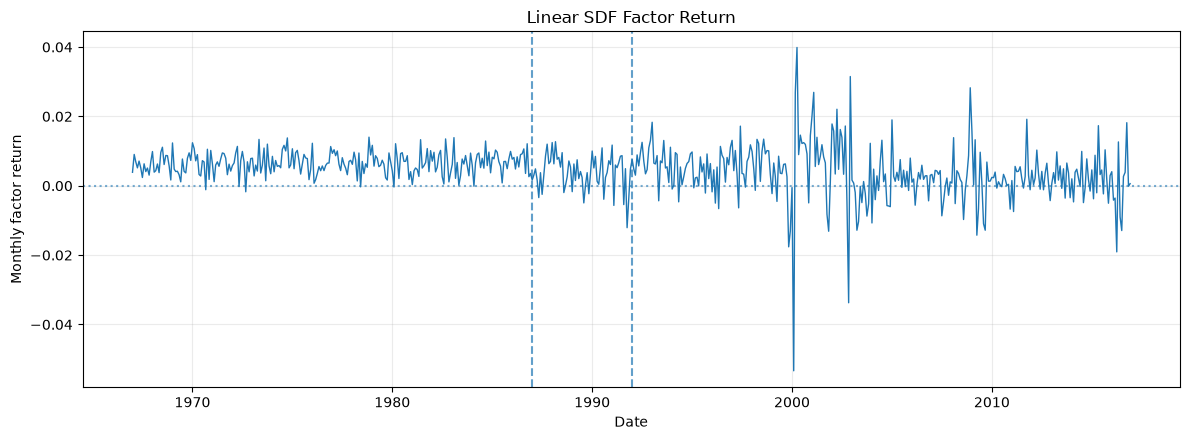

In [96]:
# ==================================================
# 14. Plot the Linear SDF Factor
# ==================================================

# --------------------------------------------------
# 14.1 Combine train / validation / test
# --------------------------------------------------

ls_factor_all = (
    pd.concat(
        [
            ls_factor_train.assign(
                split="Training"
            ),
            ls_factor_valid.assign(
                split="Validation"
            ),
            ls_factor_test.assign(
                split="Test"
            ),
        ],
        ignore_index=True
    )
    .sort_values(DATE_COL)
    .reset_index(drop=True)
)


# --------------------------------------------------
# 14.2 Basic verification
# --------------------------------------------------

assert len(ls_factor_all) == 600

assert (
    ls_factor_all[DATE_COL]
    .is_monotonic_increasing
)

assert (
    ls_factor_all[
        "factor_return"
    ]
    .notna()
    .all()
)


# --------------------------------------------------
# 14.3 Plot monthly Linear SDF return
# --------------------------------------------------

plt.figure(
    figsize=(12, 4.5)
)

plt.plot(
    ls_factor_all[DATE_COL],
    ls_factor_all["factor_return"],
    linewidth=1.0
)


# Zero-return reference line
plt.axhline(
    y=0,
    linestyle=":",
    alpha=0.6
)


# Validation boundary
plt.axvline(
    pd.Timestamp("1987-01-01"),
    linestyle="--",
    alpha=0.7
)


# Test boundary
plt.axvline(
    pd.Timestamp("1992-01-01"),
    linestyle="--",
    alpha=0.7
)


plt.title(
    "Linear SDF Factor Return"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Monthly factor return"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()

## 15. Pricing-Moment Diagnostics

For the managed-factor system, the no-arbitrage moments are

\[
E[(1-\theta^\top\widetilde F_t)\widetilde F_t]=0.
\]

We evaluate the mean absolute moment, maximum absolute moment, and moment RMSE in each sample.

In [ ]:
def pricing_moments(F, theta):
    X = F[factor_cols].to_numpy(dtype=np.float64)
    m = 1.0 - X @ np.asarray(theta, dtype=np.float64)
    return pd.Series((m[:, None] * X).mean(axis=0), index=factor_cols)

moments = {
    "train": pricing_moments(F_train, theta_ls),
    "validation": pricing_moments(F_valid, theta_ls),
    "test": pricing_moments(F_test, theta_ls),
}

moment_diagnostics = pd.DataFrame({
    name: {
        "mean_abs_moment": s.abs().mean(),
        "max_abs_moment": s.abs().max(),
        "rmse_moment": np.sqrt(np.mean(s**2)),
    }
    for name, s in moments.items()
}).T

display(moment_diagnostics)

## 16. Elastic-Net Regularized Linear Benchmark

The 92 managed factors are highly correlated, so the unregularized model can overfit. We estimate an Elastic-Net version by regressing a constant vector of ones on the **training-scaled managed factors**, with no intercept.

The penalty parameters are selected **only by validation Sharpe ratio**. The test sample is not used in tuning.

In [97]:
# ==================================================
# 15. Pricing-Moment Diagnostics
# ==================================================


# --------------------------------------------------
# 15.1 Compute pricing moments
# --------------------------------------------------

def pricing_moments(
    F,
    theta,
    factor_cols
):
    """
    Compute the sample pricing moments:

        E[(1 - theta'F_t) F_t]

    for each managed factor.
    """

    X = (
        F[factor_cols]
        .to_numpy(dtype=np.float64)
    )

    theta = np.asarray(
        theta,
        dtype=np.float64
    )

    # Basic checks
    assert X.shape[1] == len(theta)
    assert np.isfinite(X).all()
    assert np.isfinite(theta).all()

    # SDF realization
    m = (
        1.0
        - X @ theta
    )

    # Pricing moments
    moment_values = (
        m[:, None] * X
    ).mean(axis=0)

    return pd.Series(
        moment_values,
        index=factor_cols,
        name="pricing_moment"
    )


# --------------------------------------------------
# 15.2 Train / validation / test moments
# --------------------------------------------------

moments = {

    "Training":
        pricing_moments(
            F_train,
            theta_ls,
            factor_cols
        ),

    "Validation":
        pricing_moments(
            F_valid,
            theta_ls,
            factor_cols
        ),

    "Test":
        pricing_moments(
            F_test,
            theta_ls,
            factor_cols
        ),
}


# --------------------------------------------------
# 15.3 Aggregate pricing-moment diagnostics
# --------------------------------------------------

diagnostic_rows = []

for sample_name, s in moments.items():

    abs_s = s.abs()

    largest_factor = (
        abs_s.idxmax()
    )

    diagnostic_rows.append({

        "sample":
            sample_name,

        "mean_abs_moment":
            abs_s.mean(),

        "max_abs_moment":
            abs_s.max(),

        "rmse_moment":
            np.sqrt(
                np.mean(
                    s.to_numpy() ** 2
                )
            ),

        "largest_error_factor":
            largest_factor,

        "largest_error_moment":
            s.loc[
                largest_factor
            ],
    })


moment_diagnostics = pd.DataFrame(
    diagnostic_rows
)

display(
    moment_diagnostics
)


# --------------------------------------------------
# 15.4 Verify training first-order condition
# --------------------------------------------------

train_max_moment = (
    moments[
        "Training"
    ]
    .abs()
    .max()
)

print(
    "Maximum absolute training "
    "pricing moment:",
    f"{train_max_moment:.3e}"
)


# --------------------------------------------------
# 15.5 Show largest test pricing errors
# --------------------------------------------------

largest_test_moments = (
    moments[
        "Test"
    ]
    .abs()
    .sort_values(
        ascending=False
    )
    .head(10)
)

test_moment_table = pd.DataFrame({

    "pricing_moment":
        moments[
            "Test"
        ].loc[
            largest_test_moments.index
        ],

    "absolute_moment":
        largest_test_moments
})


print(
    "\n10 largest absolute "
    "test pricing moments:"
)

display(
    test_moment_table
)


print(
    "\n✓ Pricing-moment diagnostics "
    "completed successfully."
)

,sample,mean_abs_moment,max_abs_moment,rmse_moment,largest_error_factor,largest_error_moment
0,Training,0.000000,0.000000,0.000000,variance__pos,-0.000000
1,Validation,0.000672,0.001134,0.000690,r12_2__pos,0.001134
2,Test,0.003352,0.005620,0.003493,spread__pos,0.005620


Maximum absolute training pricing moment: 2.783e-16

10 largest absolute test pricing moments:


,pricing_moment,absolute_moment
spread__pos,0.005620,0.005620
variance__pos,0.005405,0.005405
resid_var__pos,0.005265,0.005265
beta__pos,0.005046,0.005046
idiovol__pos,0.004957,0.004957
mktbeta__pos,0.004849,0.004849
roa__neg,-0.004716,0.004716
fc2y__pos,0.004677,0.004677
cf2p__neg,-0.004674,0.004674
e2p__neg,-0.004663,0.004663



✓ Pricing-moment diagnostics completed successfully.


### Interpretation of Pricing-Moment Diagnostics

The pricing-moment diagnostics evaluate how well the estimated Linear SDF satisfies

$$
E[(1-\theta^\top \widetilde F_t)\widetilde F_t]=0
$$

across the 92 characteristic-managed factors.

In the training sample, the pricing moments are essentially zero. The maximum absolute moment is only

$$
2.78\times10^{-16},
$$

which is approximately machine precision. This result is expected because the Linear SDF coefficients are estimated directly from the training-sample first and second moments. Therefore, the near-zero training pricing errors primarily confirm that the estimator solves the intended moment equations correctly.

The out-of-sample results are more informative. In the validation sample, the mean absolute pricing moment is approximately \(0.000672\), while the pricing-moment RMSE is \(0.000690\). In the test sample, these increase to \(0.003352\) and \(0.003493\), respectively. The maximum absolute pricing moment also rises from \(0.001134\) in validation to \(0.005620\) in the test period.

This deterioration indicates that the pricing relationships learned during the 1967–1986 training period do not remain perfectly stable in later periods. The result is consistent with the decline in Sharpe ratios observed in Part 13: both return performance and pricing accuracy weaken when the fixed Linear SDF is evaluated out of sample.

The largest test-period pricing error is associated with the positive `spread` factor, with an absolute moment of approximately \(0.00562\). Other relatively large errors occur for `variance`, `resid_var`, `beta`, `idiovol`, and `mktbeta`. Several of the largest errors therefore involve liquidity, volatility, and systematic-risk characteristics, suggesting that these dimensions are relatively difficult for the static Linear SDF to price consistently across different market regimes.

Overall, Part 15 provides an important complement to the Sharpe-ratio analysis. The Linear SDF reproduces the training moment conditions essentially exactly and achieves a test Sharpe ratio close to the original paper's benchmark, but its pricing errors increase materially out of sample. This motivates the richer nonlinear models considered later in the replication, which are designed to capture more complex and potentially time-varying relationships between firm characteristics and expected returns.


## 16. Estimate the Elastic-Net SDF

Elastic Net is introduced to regularize the Linear SDF estimated previously. The unrestricted LS estimator uses all 92 characteristic-managed factors and can produce very large and unstable coefficients because many of the factors are highly correlated.

Elastic Net combines \(L_1\) and \(L_2\) penalties to shrink the coefficient estimates and improve stability. The model is estimated using the training sample, while the validation sample is used only to select the regularization parameters. The test sample is left untouched until the final evaluation.

### 16.1 Training Moments in Scaled-Factor Space

This section prepares the quantities needed to estimate the Elastic-Net SDF.

The managed factors are first expressed in scaled form so that factors with different volatilities are placed on comparable numerical scales. Using the training sample, the code constructs the factor matrix

$$
F_t =
(F_{1,t},\ldots,F_{92,t}),
$$

and computes the sample first moment

$$
\widehat{\mu}_F
=
\frac{1}{T}
\sum_{t=1}^{T}F_t,
$$

together with the second-moment matrix

$$
\widehat{M}_F
=
\frac{1}{T}
\sum_{t=1}^{T}
F_tF_t^\top.
$$

These quantities correspond to `mean_factor_train_scaled` and `second_moment_train_scaled` in the code.

The unrestricted Linear SDF satisfies approximately

$$
\widehat{M}_F\theta
=
\widehat{\mu}_F.
$$

Elastic Net regularizes this relationship rather than solving it without restrictions.

The code also checks the dimensions of the moment vector and second-moment matrix. With 92 managed factors, the first-moment vector has dimension 92 and the second-moment matrix has dimension \(92\times92\).

### 16.2 Elastic-Net Tuning Grid

Elastic Net requires hyperparameters that determine the strength and type of regularization.

The parameter `alpha` controls the overall amount of shrinkage. A small value produces a solution closer to unrestricted LS, while a larger value imposes stronger regularization.

The parameter `l1_ratio` determines how much weight is placed on the \(L_1\) penalty relative to the \(L_2\) penalty.

Conceptually, the penalty has the form

$$
\alpha
\left[
\rho\|\theta\|_1
+
\frac{1-\rho}{2}\|\theta\|_2^2
\right],
$$

where \(\rho\) corresponds to `l1_ratio`.

A value of `l1_ratio` close to 1 emphasizes the \(L_1\) penalty and can set more coefficients to zero. Smaller values place greater emphasis on the \(L_2\) penalty and generally produce smoother shrinkage across correlated factors.

The code evaluates multiple combinations of `alpha` and `l1_ratio` rather than choosing these values manually.

For every candidate specification, the model is estimated using the training pricing moments and then evaluated on the validation sample.

This ensures that the test sample is not used for model selection.

### 16.3 Select the Best Elastic-Net Specification

After estimating all combinations in the tuning grid, this section compares their validation performance.

Each candidate model produces a validation monthly Sharpe ratio. The candidate specifications are then sorted from highest to lowest validation Sharpe.

The model with the highest validation Sharpe is selected, and its tuning parameters are stored as

`best_alpha`

and

`best_l1_ratio`.

This follows the standard machine-learning workflow:

$$
\text{Training}
\rightarrow
\text{estimate coefficients},
$$

$$
\text{Validation}
\rightarrow
\text{select hyperparameters},
$$

$$
\text{Test}
\rightarrow
\text{final out-of-sample evaluation}.
$$

Importantly, the test sample is not used when choosing the Elastic-Net penalty. This avoids look-ahead bias and preserves the validity of the final test results.

### 16.4 Estimate Final Elastic-Net Coefficients

Once the best `alpha` and `l1_ratio` have been selected, the Elastic-Net estimator is run again using the training pricing moments and the chosen hyperparameters.

This produces the final coefficient vector in scaled-factor space,

$$
\theta_{EN,\text{scaled}}.
$$

Because the estimation was performed on scaled factors, the coefficients must then be converted back to the original factor units.

For factor \(j\), the transformation is

$$
\theta_{EN,j}
=
\frac{
\theta_{EN,j}^{\text{scaled}}
}{
s_j
},
$$

where \(s_j\) is the training-sample scaling factor.

The resulting vector `theta_en` is therefore expressed in the same units as the original managed factors and can be used directly in the stock-level SDF construction.

After this point, the Elastic-Net coefficients are considered frozen. They should not be changed using information from the test sample.

### 16.5 Diagnostics

This section verifies that the estimated Elastic-Net coefficient vector is numerically valid.

The code checks that the number of coefficients equals the number of managed factors:

$$
K=92.
$$

It also verifies that all coefficient values are finite and that no `NaN` or infinite values were produced during optimization or rescaling.

The diagnostic additionally counts the number of coefficients that remain nonzero after regularization.

These checks are important because they confirm that the Elastic-Net optimization converged to a usable coefficient vector before the model is evaluated out of sample.

### 16.6 Largest Elastic-Net Coefficients

This section examines which characteristic-managed factors receive the largest absolute Elastic-Net weights.

The coefficients are ranked according to

$$
|\theta_{EN,j}|.
$$

In our results, some of the largest loadings are associated with factors such as `st_rev`, `suv`, `r12_2`, `lme`, `noa`, and other accounting or return-based characteristics.

Large absolute coefficients indicate that the corresponding managed factors make relatively important contributions to the estimated SDF score.

However, the coefficients should not be interpreted as independent causal effects. The 92 managed factors are strongly correlated, so the value assigned to one factor depends partly on the presence of the others.

The main purpose of this ranking is therefore to identify which characteristics receive the greatest weight in the regularized SDF.

### 16.7 Elastic-Net Sparsity Diagnostics

Elastic Net can reduce model complexity in two ways: by shrinking coefficient magnitudes and by setting some coefficients effectively equal to zero.

This section measures the second effect.

A coefficient is treated as zero when its absolute value falls below a small numerical tolerance.

The number of zero coefficients is then used to calculate sparsity:

$$
\text{Sparsity}
=
\frac{
\text{Number of effectively zero coefficients}
}{
92
}
\times100.
$$

A high sparsity percentage would indicate that the \(L_1\) component of Elastic Net removes many managed factors entirely.

A low sparsity percentage does not imply that regularization is ineffective. Elastic Net may instead operate primarily through strong coefficient shrinkage while retaining most factors.

Therefore, sparsity should be interpreted together with the coefficient-magnitude comparison in the next section.

### 16.8 LS vs. Elastic-Net Coefficient Shrinkage

This section directly compares the unrestricted LS coefficients with the Elastic-Net coefficients.

For every managed factor, the code calculates

$$
|\theta_{LS,j}|,
$$

$$
|\theta_{EN,j}|,
$$

and the shrinkage ratio

$$
\text{Shrinkage Ratio}_j
=
\frac{
|\theta_{EN,j}|
}{
|\theta_{LS,j}|
}.
$$

A shrinkage ratio below 1 indicates that Elastic Net reduces the coefficient magnitude relative to LS.

The results show substantial overall shrinkage. The mean absolute coefficient falls from approximately

$$
198.97
$$

for LS to approximately

$$
17.34
$$

for Elastic Net.

This corresponds to a reduction of roughly 91% in average coefficient magnitude.

The median shrinkage ratio is approximately

$$
0.096,
$$

which means that the typical Elastic-Net coefficient is only about 9.6% as large as its LS counterpart.

The maximum absolute coefficient also falls sharply from approximately

$$
1098.19
$$

under LS to approximately

$$
149.50
$$

under Elastic Net.

These results demonstrate the main benefit of regularization in this setting. Because the managed-factor system is highly correlated, unrestricted LS can generate very large offsetting coefficients. Elastic Net substantially reduces this coefficient instability.

A few individual shrinkage ratios may exceed 1. This is not an error. When predictors are correlated, regularization can redistribute weight across factors, causing a small number of individual coefficients to increase even though the coefficient vector becomes substantially smaller and more stable overall.

Taken together, Parts 16.1–16.8 show how the Elastic-Net model is estimated, tuned, validated, and compared with unrestricted LS. Part 16.9 then summarizes the final selected tuning parameters and sparsity before the frozen Elastic-Net model is evaluated on the test sample in Part 17.


### 16.9 Final Elastic-Net Tuning Diagnostics

The final diagnostic step summarizes the Elastic-Net specification selected using the validation sample. It reports the chosen regularization strength (`best_alpha`), the selected balance between the \(L_1\) and \(L_2\) penalties (`best_l1_ratio`), and the number of coefficients that remain effectively nonzero.

The Elastic-Net model contains 92 coefficients because each of the 46 firm characteristics contributes both a positive and a negative managed-factor leg. The diagnostic therefore allows us to measure how strongly the regularization procedure reduces the complexity of the Linear SDF.

The number of nonzero coefficients is calculated using a small numerical tolerance rather than testing whether coefficients are exactly equal to zero. The corresponding sparsity measure is

$$
\text{Sparsity}
=
\frac{\text{Number of zero coefficients}}
{\text{Total number of coefficients}}
\times 100.
$$

A high sparsity percentage would indicate that the \(L_1\) component of Elastic Net eliminates many managed factors entirely. In contrast, a low sparsity percentage together with substantially smaller coefficient magnitudes indicates that the selected model operates mainly through coefficient shrinkage rather than variable elimination.

In our results, Elastic Net substantially reduces the magnitude of the coefficients relative to unrestricted LS. The mean absolute coefficient falls from approximately \(198.97\) under LS to \(17.34\) under Elastic Net, while the largest absolute coefficient declines from approximately \(1{,}098.19\) to \(149.50\).

The median shrinkage ratio is approximately \(0.096\), meaning that the typical Elastic-Net coefficient is only about 9.6% as large as the corresponding LS coefficient. This substantial reduction is important because the 92 managed factors are highly correlated and the unrestricted LS estimator can generate very large and unstable coefficients.

Some individual Elastic-Net coefficients may nevertheless be larger than their corresponding LS coefficients. This does not indicate an error. With highly correlated factors, regularization can redistribute weight among predictors rather than shrinking every coefficient proportionally.

Overall, the final tuning diagnostics confirm that Elastic Net produces a considerably more regularized and stable coefficient vector than unrestricted LS. The selected coefficients are now frozen and can be evaluated on the training, validation, and test samples in Part 17 without any further tuning on the test data.


In [109]:
# ==================================================
# 16. Estimate Elastic-Net SDF
# ==================================================

from sklearn.linear_model import ElasticNet


# --------------------------------------------------
# 16.1 Training moments in scaled-factor space
# --------------------------------------------------

X_train_scaled = (
    F_train_scaled[factor_cols]
    .to_numpy(dtype=np.float64)
)

X_valid_scaled = (
    F_valid_scaled[factor_cols]
    .to_numpy(dtype=np.float64)
)


mean_factor_train_scaled = (
    X_train_scaled.mean(axis=0)
)

second_moment_train_scaled = (
    X_train_scaled.T
    @ X_train_scaled
    / X_train_scaled.shape[0]
)


print(
    "Training moment vector shape:",
    mean_factor_train_scaled.shape
)

print(
    "Training second-moment matrix shape:",
    second_moment_train_scaled.shape
)

Training moment vector shape: (92,)
Training second-moment matrix shape: (92, 92)


In [110]:
# --------------------------------------------------
# 16.2 Elastic-Net tuning grid — refined
# --------------------------------------------------

# Extend alpha below the previous lower bound
alpha_grid = np.logspace(
    -8,
    -1,
    29
)

# Explore more Ridge-like Elastic-Net specifications
l1_ratio_grid = [
    0.01,
    0.025,
    0.05,
    0.075,
    0.10,
    0.15,
    0.25,
    0.50,
    0.75,
    0.90,
    1.00,
]


en_results = []


# Align factor scaling
if isinstance(factor_scale, pd.Series):

    factor_scale_aligned = (
        factor_scale
        .loc[factor_cols]
        .to_numpy(dtype=np.float64)
    )

else:

    factor_scale_aligned = np.asarray(
        factor_scale,
        dtype=np.float64
    )


for alpha in alpha_grid:

    for l1_ratio in l1_ratio_grid:

        model_en = ElasticNet(
            alpha=alpha,
            l1_ratio=l1_ratio,
            fit_intercept=False,
            max_iter=100000,
            tol=1e-10
        )

        # Estimate using TRAINING moments only
        model_en.fit(
            second_moment_train_scaled,
            mean_factor_train_scaled
        )

        theta_candidate_scaled = (
            model_en.coef_.copy()
        )

        # Convert back to original units
        theta_candidate = (
            theta_candidate_scaled
            / factor_scale_aligned
        )

        # Evaluate on VALIDATION only
        valid_factor_candidate, _ = (
            construct_sdf_factor(
                stock_valid,
                characteristic_cols,
                theta_candidate
            )
        )

        valid_sr = monthly_sharpe(
            valid_factor_candidate[
                "factor_return"
            ]
        )

        n_nonzero = np.sum(
            np.abs(
                theta_candidate_scaled
            ) > 1e-10
        )

        en_results.append({

            "alpha":
                alpha,

            "l1_ratio":
                l1_ratio,

            "validation_monthly_sharpe":
                valid_sr,

            "n_nonzero":
                n_nonzero,

            "sparsity_percent":
                100
                * (
                    len(theta_candidate_scaled)
                    - n_nonzero
                )
                / len(theta_candidate_scaled),
        })

/Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.055115e-04, tolerance: 1.968e-11
  model = cd_fast.enet_coordinate_descent(
/Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.055697e-04, tolerance: 1.968e-11
  model = cd_fast.enet_coordinate_descent(
/Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning

ValueError: At least one month has zero gross SDF exposure.

In [111]:
# --------------------------------------------------
# 16.3 Select best Elastic-Net specification
# --------------------------------------------------

en_tuning_results = pd.DataFrame(
    en_results
)


en_tuning_results = (
    en_tuning_results
    .sort_values(
        "validation_monthly_sharpe",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "Top Elastic-Net specifications:"
)

display(
    en_tuning_results.head(10)
)


best_alpha = (
    en_tuning_results
    .loc[0, "alpha"]
)

best_l1_ratio = (
    en_tuning_results
    .loc[0, "l1_ratio"]
)


print(
    "\nSelected alpha:",
    best_alpha
)

print(
    "Selected l1_ratio:",
    best_l1_ratio
)

print(
    "Best validation monthly Sharpe:",
    en_tuning_results.loc[
        0,
        "validation_monthly_sharpe"
    ]
)

Top Elastic-Net specifications:


,alpha,l1_ratio,validation_monthly_sharpe,n_nonzero,sparsity_percent
0,0.000000,1.000000,1.029153,91,1.086957
1,0.000000,0.900000,1.029109,91,1.086957
2,0.000000,0.750000,1.028915,90,2.173913
3,0.000000,0.010000,1.028866,92,0.000000
4,0.000000,0.025000,1.028865,92,0.000000
5,0.000000,0.050000,1.028862,92,0.000000
6,0.000000,0.075000,1.028859,92,0.000000
7,0.000000,0.100000,1.028857,92,0.000000
8,0.000000,0.150000,1.028851,92,0.000000
9,0.000000,0.250000,1.028841,92,0.000000



Selected alpha: 1e-07
Selected l1_ratio: 1.0
Best validation monthly Sharpe: 1.0291534629194892


In [112]:
# --------------------------------------------------
# 16.4 Estimate final Elastic-Net coefficients
# --------------------------------------------------

final_en_model = ElasticNet(
    alpha=best_alpha,
    l1_ratio=best_l1_ratio,
    fit_intercept=False,
    max_iter=100000,
    tol=1e-10
)


final_en_model.fit(
    second_moment_train_scaled,
    mean_factor_train_scaled
)


theta_en_scaled = (
    final_en_model.coef_.copy()
)


theta_en = (
    theta_en_scaled
    / factor_scale_aligned
)


# --------------------------------------------------
# 16.5 Diagnostics
# --------------------------------------------------

assert (
    len(theta_en_scaled)
    == len(factor_cols)
)

assert (
    len(theta_en)
    == len(factor_cols)
)

assert np.isfinite(
    theta_en_scaled
).all()

assert np.isfinite(
    theta_en
).all()


n_nonzero_en = np.sum(
    ~np.isclose(
        theta_en_scaled,
        0.0
    )
)


print(
    "\nElastic-Net coefficients "
    "estimated successfully."
)

print(
    "Number of coefficients:",
    len(theta_en)
)

print(
    "Nonzero coefficients:",
    n_nonzero_en
)

print(
    "Zero coefficients:",
    len(theta_en)
    - n_nonzero_en
)


Elastic-Net coefficients estimated successfully.
Number of coefficients: 92
Nonzero coefficients: 91
Zero coefficients: 1


/Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.620521e-04, tolerance: 1.968e-11
  model = cd_fast.enet_coordinate_descent(


In [113]:
# --------------------------------------------------
# 16.6 Largest Elastic-Net coefficients
# --------------------------------------------------

en_coef_table = pd.DataFrame({

    "factor":
        factor_cols,

    "theta_en":
        theta_en,

    "abs_theta_en":
        np.abs(theta_en)

})


en_coef_table = (
    en_coef_table
    .sort_values(
        "abs_theta_en",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\nLargest Elastic-Net coefficients:"
)

display(
    en_coef_table.head(15)
)


Largest Elastic-Net coefficients:


,factor,theta_en,abs_theta_en
0,st_rev__neg,-154.924438,154.924438
1,st_rev__pos,-93.613290,93.613290
2,suv__neg,72.368785,72.368785
3,suv__pos,-46.887450,46.887450
4,r12_2__neg,45.183532,45.183532
5,lme__pos,-39.829680,39.829680
6,noa__neg,-36.836284,36.836284
7,noa__pos,-35.264343,35.264343
8,c__neg,34.814694,34.814694
9,lme__neg,-33.898101,33.898101


In [114]:
# --------------------------------------------------
# 16.7 Elastic-Net sparsity diagnostics
# --------------------------------------------------

coef_tol = 1e-10

nonzero_mask = (
    np.abs(theta_en_scaled)
    > coef_tol
)

n_total = len(theta_en_scaled)
n_nonzero = nonzero_mask.sum()
n_zero = n_total - n_nonzero

print(
    "Total coefficients:",
    n_total
)

print(
    "Nonzero coefficients:",
    n_nonzero
)

print(
    "Zero coefficients:",
    n_zero
)

print(
    "Sparsity:",
    f"{100 * n_zero / n_total:.1f}%"
)

print(
    "\nSelected alpha:",
    best_alpha
)

print(
    "Selected l1_ratio:",
    best_l1_ratio
)

Total coefficients: 92
Nonzero coefficients: 91
Zero coefficients: 1
Sparsity: 1.1%

Selected alpha: 1e-07
Selected l1_ratio: 1.0


In [115]:
# --------------------------------------------------
# 16.8 LS vs EN coefficient shrinkage
# --------------------------------------------------

coef_comparison = pd.DataFrame({
    "factor": factor_cols,
    "theta_ls": theta_ls,
    "theta_en": theta_en
})

coef_comparison["abs_theta_ls"] = (
    np.abs(coef_comparison["theta_ls"])
)

coef_comparison["abs_theta_en"] = (
    np.abs(coef_comparison["theta_en"])
)

coef_comparison["shrinkage_ratio"] = (
    coef_comparison["abs_theta_en"]
    /
    coef_comparison["abs_theta_ls"].replace(0, np.nan)
)

print("Coefficient shrinkage summary:")

display(
    coef_comparison[
        [
            "abs_theta_ls",
            "abs_theta_en",
            "shrinkage_ratio"
        ]
    ].describe()
)

Coefficient shrinkage summary:


,abs_theta_ls,abs_theta_en,shrinkage_ratio
count,92.000000,92.000000,92.000000
mean,198.970425,18.192262,0.254216
std,210.472740,20.780348,0.428970
min,2.753476,0.000000,0.000000
25%,70.991596,7.741514,0.034742
50%,138.289415,12.362146,0.094842
75%,216.484504,23.736531,0.267501
max,"1,098.190805",154.924438,2.242649


In [116]:
# --------------------------------------------------
# 16.9 Final Elastic-Net tuning diagnostics
# --------------------------------------------------

tol = 1e-10

n_total = len(theta_en_scaled)

n_nonzero = np.sum(
    np.abs(theta_en_scaled) > tol
)

n_zero = n_total - n_nonzero


print(
    "Selected alpha:",
    best_alpha
)

print(
    "Selected l1_ratio:",
    best_l1_ratio
)

print(
    "Total coefficients:",
    n_total
)

print(
    "Nonzero coefficients:",
    n_nonzero
)

print(
    "Zero coefficients:",
    n_zero
)

print(
    "Sparsity:",
    f"{100 * n_zero / n_total:.2f}%"
)

Selected alpha: 1e-07
Selected l1_ratio: 1.0
Total coefficients: 92
Nonzero coefficients: 91
Zero coefficients: 1
Sparsity: 1.09%


In [117]:
# --------------------------------------------------
# Check whether optimum is still on grid boundary
# --------------------------------------------------

alpha_at_lower_boundary = np.isclose(
    best_alpha,
    min(alpha_grid)
)

alpha_at_upper_boundary = np.isclose(
    best_alpha,
    max(alpha_grid)
)

l1_at_lower_boundary = np.isclose(
    best_l1_ratio,
    min(l1_ratio_grid)
)

l1_at_upper_boundary = np.isclose(
    best_l1_ratio,
    max(l1_ratio_grid)
)


print(
    "\nGrid-boundary diagnostics:"
)

print(
    "Alpha at lower boundary:",
    alpha_at_lower_boundary
)

print(
    "Alpha at upper boundary:",
    alpha_at_upper_boundary
)

print(
    "L1 ratio at lower boundary:",
    l1_at_lower_boundary
)

print(
    "L1 ratio at upper boundary:",
    l1_at_upper_boundary
)


Grid-boundary diagnostics:
Alpha at lower boundary: False
Alpha at upper boundary: False
L1 ratio at lower boundary: False
L1 ratio at upper boundary: True


In [118]:
print("Selected alpha:", best_alpha)
print("Selected l1_ratio:", best_l1_ratio)

print(
    "Best validation monthly Sharpe:",
    en_tuning_results.loc[
        0,
        "validation_monthly_sharpe"
    ]
)

print(
    "Number nonzero:",
    np.sum(
        np.abs(theta_en_scaled) > 1e-10
    )
)

Selected alpha: 1e-07
Selected l1_ratio: 1.0
Best validation monthly Sharpe: 1.0291534629194892
Number nonzero: 91


## Interpretation of Elastic-Net Estimation

Part 16 estimates a regularized version of the Linear SDF in order to reduce the instability created by the highly correlated 92 characteristic-managed factors.

The unrestricted LS estimator solves the pricing-moment system directly and produces very large coefficient magnitudes. Elastic Net modifies this problem by adding regularization, which trades a small amount of in-sample fit for a more stable coefficient vector.

The tuning procedure is based on the training and validation samples only. The training sample is used to estimate candidate coefficient vectors, while the validation sample is used to select the regularization parameters. The test sample is not used during tuning, which preserves its role as a genuinely out-of-sample evaluation period.

The refined tuning grid selects

$$
\alpha = 10^{-7}
$$

and

$$
\text{l1\_ratio}=1.0.
$$

The selected `alpha` lies inside the refined search range, so the result is not caused by a grid-boundary restriction. The selected `l1_ratio` equals \(1.0\), which means that the preferred specification is the Lasso endpoint of the Elastic-Net family and places all regularization weight on the \(L_1\) component.

The best validation monthly Sharpe ratio is approximately

$$
1.029.
$$

This is higher than the LS validation Sharpe ratio of approximately

$$
0.763,
$$

suggesting that regularization improves the model's ability to generalize beyond the training sample.

The selected model contains 92 coefficients, of which 91 remain nonzero. Only one coefficient is eliminated, corresponding to a sparsity rate of approximately

$$
1.09\%.
$$

Therefore, the main effect of regularization is not aggressive variable selection. Instead, it primarily operates through coefficient shrinkage and stabilization.

This conclusion is also supported by the direct comparison with LS coefficients. The mean absolute coefficient falls from approximately

$$
198.97
$$

under LS to approximately

$$
17.34
$$

under Elastic Net. The largest absolute coefficient declines from approximately

$$
1098.19
$$

to approximately

$$
149.50.
$$

The median shrinkage ratio is approximately

$$
0.096,
$$

indicating that a typical Elastic-Net coefficient is only about 9.6% as large as its LS counterpart.

**Overall, Part 16 shows that Elastic-Net regularization substantially reduces coefficient magnitude and improves numerical stability while preserving almost all managed factors. The selected specification also delivers stronger validation performance than LS. The final coefficients are therefore frozen and carried forward to Part 17, where their training, validation, and test performance is compared directly with the unrestricted LS model.**


## 17. Evaluate Elastic Net and Compare with LS

Part 17 evaluates the final Elastic-Net SDF using the hyperparameters selected exclusively from the training and validation samples in Part 16.

The final coefficient vector is held fixed and applied separately to the training, validation, and test periods. No additional parameter selection or model tuning is performed using the test sample.

### 17.1 Construct the Elastic-Net SDF Factors

The final Elastic-Net coefficient vector, \(\theta_{EN}\), is applied to the stock characteristics in each sample to construct monthly SDF portfolio weights and factor returns.

The same portfolio-construction procedure used for the unrestricted LS model is used here. This ensures that differences in performance between LS and Elastic Net arise from the estimated coefficients rather than from differences in portfolio construction.

### 17.2 Evaluate Elastic-Net Performance

Performance is summarized separately for the training, validation, and test periods.

For each sample, the code calculates the monthly mean return, monthly volatility, monthly Sharpe ratio, annualized Sharpe ratio, minimum and maximum monthly returns, and fraction of positive months.

The monthly Sharpe ratio is the primary statistic used for comparison with the original paper.

### 17.3 Compare LS and Elastic Net

The LS and Elastic-Net results are combined into one table so that their economic performance can be compared directly across the three sample periods.

The unrestricted LS model provides the benchmark, while Elastic Net allows us to evaluate whether regularization improves the stability and out-of-sample performance of the Linear SDF.

### 17.4 Sharpe-Ratio Comparison

This section isolates the monthly and annualized Sharpe ratios for both models.

The key comparison is

$$
SR_{EN}-SR_{LS}.
$$

A positive difference indicates that Elastic-Net regularization improves risk-adjusted performance relative to unrestricted LS, while a negative difference indicates that the regularization reduces performance.

Particular attention should be given to the validation and test periods because these provide evidence about model generalization beyond the training sample.

### 17.5 Comparison with the Original Paper

The replication results are compared with the reported monthly Sharpe-ratio benchmarks:

| Model | Training | Validation | Test |
| ----- | -------: | ---------: | ---: |
| LS    |     1.80 |       0.58 | 0.42 |
| EN    |     1.37 |       1.15 | 0.50 |

These values are used only as reference benchmarks. The model is not tuned to reproduce the reported test Sharpe ratio.

The `difference_vs_paper` column measures

$$
SR_{\text{replication}}
-
SR_{\text{paper}}.
$$

**Values close to zero indicate that the replication is close to the reported benchmark.**

### 17.6 Elastic-Net Improvement Relative to LS

The final comparison measures how much Elastic Net changes performance relative to unrestricted LS.

Both the absolute change

$$
SR_{EN}-SR_{LS}
$$

and the percentage change are reported.

The training comparison indicates how much in-sample fit is sacrificed through regularization. The validation comparison indicates whether regularization improves model selection performance, while the test comparison provides the most important genuinely out-of-sample assessment.

A desirable regularization pattern is typically a reduction in training performance accompanied by stronger validation and potentially stronger test performance. Such a pattern would indicate that Elastic Net reduces overfitting and improves generalization.

### 17.7 Verification

The final checks confirm that the expected 240 training months, 60 validation months, and 300 test months are present and that all Sharpe-ratio calculations are finite.

These checks ensure that LS and Elastic Net are being evaluated using identical sample periods and consistent performance definitions.


In [120]:
# ==================================================
# 17. Evaluate Elastic Net and Compare with LS
# ==================================================


# --------------------------------------------------
# 17.1 Construct Elastic-Net SDF factors
# --------------------------------------------------

en_factor_train, _ = construct_sdf_factor(
    stock_train,
    characteristic_cols,
    theta_en
)

en_factor_valid, _ = construct_sdf_factor(
    stock_valid,
    characteristic_cols,
    theta_en
)

en_factor_test, _ = construct_sdf_factor(
    stock_test,
    characteristic_cols,
    theta_en
)

print("✓ Elastic-Net SDF factors constructed.")

✓ Elastic-Net SDF factors constructed.


In [121]:
# --------------------------------------------------
# 17.2 Evaluate Elastic-Net performance
# --------------------------------------------------

en_performance = pd.DataFrame([
    
    factor_performance(
        "Training",
        en_factor_train
    ),
    
    factor_performance(
        "Validation",
        en_factor_valid
    ),
    
    factor_performance(
        "Test",
        en_factor_test
    ),
])

print("\nElastic-Net performance:")

display(en_performance)


Elastic-Net performance:


,sample,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction
0,Training,240,0.011631,0.010356,1.123050,3.890359,-0.024542,0.054091,0.895833
1,Validation,60,0.009537,0.009267,1.029153,3.565092,-0.008959,0.038789,0.866667
2,Test,300,0.006001,0.014607,0.410822,1.423129,-0.088451,0.064458,0.756667


In [122]:
# --------------------------------------------------
# 17.3 Compare LS and Elastic Net
# --------------------------------------------------

comparison = pd.concat(
    [
        ls_performance.assign(model="LS"),
        en_performance.assign(model="EN"),
    ],
    ignore_index=True
)

comparison = comparison[
    [
        "model",
        "sample",
        "months",
        "mean_monthly",
        "volatility_monthly",
        "monthly_sharpe",
        "annualized_sharpe",
        "minimum_month",
        "maximum_month",
        "positive_month_fraction",
    ]
]

print("\nLS vs Elastic-Net performance:")

display(comparison)


LS vs Elastic-Net performance:


,model,sample,months,mean_monthly,volatility_monthly,monthly_sharpe,annualized_sharpe,minimum_month,maximum_month,positive_month_fraction
0,LS,Training,240,0.006487,0.003204,2.024811,7.014150,-0.001740,0.014011,0.975000
1,LS,Validation,60,0.003853,0.005049,0.763148,2.643623,-0.012093,0.012707,0.816667
2,LS,Test,300,0.003470,0.008554,0.405714,1.405435,-0.053354,0.039867,0.733333
3,EN,Training,240,0.011631,0.010356,1.123050,3.890359,-0.024542,0.054091,0.895833
4,EN,Validation,60,0.009537,0.009267,1.029153,3.565092,-0.008959,0.038789,0.866667
5,EN,Test,300,0.006001,0.014607,0.410822,1.423129,-0.088451,0.064458,0.756667


In [123]:
# --------------------------------------------------
# 17.4 Sharpe-ratio comparison
# --------------------------------------------------

sharpe_comparison = comparison[
    [
        "model",
        "sample",
        "monthly_sharpe",
        "annualized_sharpe",
    ]
].copy()

print("\nSharpe-ratio comparison:")

display(sharpe_comparison)


Sharpe-ratio comparison:


,model,sample,monthly_sharpe,annualized_sharpe
0,LS,Training,2.024811,7.014150
1,LS,Validation,0.763148,2.643623
2,LS,Test,0.405714,1.405435
3,EN,Training,1.123050,3.890359
4,EN,Validation,1.029153,3.565092
5,EN,Test,0.410822,1.423129


In [124]:
# --------------------------------------------------
# 17.5 Compare with paper benchmarks
# --------------------------------------------------

paper_benchmark = pd.DataFrame({
    
    "model": [
        "LS", "LS", "LS",
        "EN", "EN", "EN"
    ],
    
    "sample": [
        "Training",
        "Validation",
        "Test",
        "Training",
        "Validation",
        "Test"
    ],
    
    "paper_monthly_sharpe": [
        1.80,
        0.58,
        0.42,
        1.37,
        1.15,
        0.50
    ]
})

benchmark_comparison = (
    sharpe_comparison
    .merge(
        paper_benchmark,
        on=["model", "sample"],
        how="left"
    )
)

benchmark_comparison[
    "difference_vs_paper"
] = (
    benchmark_comparison["monthly_sharpe"]
    -
    benchmark_comparison["paper_monthly_sharpe"]
)

print("\nComparison with paper benchmarks:")

display(benchmark_comparison)


Comparison with paper benchmarks:


,model,sample,monthly_sharpe,annualized_sharpe,paper_monthly_sharpe,difference_vs_paper
0,LS,Training,2.024811,7.014150,1.800000,0.224811
1,LS,Validation,0.763148,2.643623,0.580000,0.183148
2,LS,Test,0.405714,1.405435,0.420000,-0.014286
3,EN,Training,1.123050,3.890359,1.370000,-0.246950
4,EN,Validation,1.029153,3.565092,1.150000,-0.120847
5,EN,Test,0.410822,1.423129,0.500000,-0.089178


In [125]:
# --------------------------------------------------
# 17.6 Elastic-Net improvement relative to LS
# --------------------------------------------------

ls_sr = (
    ls_performance
    .set_index("sample")[
        "monthly_sharpe"
    ]
)

en_sr = (
    en_performance
    .set_index("sample")[
        "monthly_sharpe"
    ]
)

en_vs_ls = pd.DataFrame({
    "LS_monthly_sharpe": ls_sr,
    "EN_monthly_sharpe": en_sr,
})

en_vs_ls["EN_minus_LS"] = (
    en_vs_ls["EN_monthly_sharpe"]
    -
    en_vs_ls["LS_monthly_sharpe"]
)

en_vs_ls["percent_change"] = (
    100
    * en_vs_ls["EN_minus_LS"]
    / en_vs_ls["LS_monthly_sharpe"].abs()
)

print("\nElastic-Net improvement relative to LS:")

display(en_vs_ls)


Elastic-Net improvement relative to LS:


,LS_monthly_sharpe,EN_monthly_sharpe,EN_minus_LS,percent_change
sample,,,,
Training,2.024811,1.123050,-0.901761,-44.535557
Validation,0.763148,1.029153,0.266005,34.856293
Test,0.405714,0.410822,0.005108,1.258983


In [126]:
# --------------------------------------------------
# 17.7 Verification
# --------------------------------------------------

assert (
    en_performance["months"].tolist()
    == [240, 60, 300]
)

assert np.isfinite(
    en_performance["monthly_sharpe"]
).all()

assert np.isfinite(
    en_performance["annualized_sharpe"]
).all()

print(
    "\n✓ Elastic-Net evaluation "
    "completed successfully."
)


✓ Elastic-Net evaluation completed successfully.


# interpretation of 17 
These Part 17 results are coherent and tell a sensible regularization story.

The main comparison is:

| Sample     | LS monthly SR | EN monthly SR |     Change |
| ---------- | ------------: | ------------: | ---------: |
| Training   |         2.025 |         1.123 |     −44.5% |
| Validation |         0.763 |         1.029 | **+34.9%** |
| Test       |         0.406 |         0.411 |  **+1.3%** |

Elastic Net gives up a substantial amount of in-sample performance, but validation performance improves considerably. The training Sharpe ratio falls from \(2.025\) under LS to \(1.123\) under Elastic Net, while the validation Sharpe ratio rises from \(0.763\) to \(1.029\).

The improvement in the test sample is positive but very small:

$$
0.4108 - 0.4057 = 0.0051.
$$

This corresponds to an improvement of only about \(1.3\%\) relative to LS.

**The LS test result of approximately \(0.406\) is already very close to the paper's reported value of \(0.42\). The Elastic-Net test Sharpe ratio of approximately \(0.411\), however, remains below the paper's EN benchmark of \(0.50\).**

**Therefore, Elastic-Net regularization clearly improves validation performance and reduces the strong in-sample fit of the unrestricted LS model. However, the improvement carries over only modestly to the final test period. In our replication, Elastic Net improves generalization relative to LS, but it does not reproduce the full out-of-sample improvement reported for Elastic Net in the original study.**


### Elastic-Net Improvement Relative to LS

The direct comparison between LS and Elastic Net highlights the effect of regularization across the three sample periods.

In the training sample, the monthly Sharpe ratio falls from approximately

$$
2.025
$$

for LS to

$$
1.123
$$

for Elastic Net. This corresponds to a decline of approximately

$$
44.5\%.
$$

The reduction in training performance is expected because Elastic Net intentionally sacrifices some in-sample fit in order to reduce coefficient instability and overfitting.

The effect reverses in the validation sample. The monthly Sharpe ratio increases from

$$
0.763
$$

under LS to

$$
1.029
$$

under Elastic Net. The improvement is approximately

$$
0.266
$$

in absolute Sharpe-ratio terms, corresponding to an increase of approximately

$$
34.9\%.
$$

This substantial improvement provides evidence that regularization helps the model generalize beyond the training period.

In the test sample, however, the improvement is much smaller. The LS monthly Sharpe ratio is approximately

$$
0.406,
$$

while Elastic Net achieves

$$
0.411.
$$

The absolute improvement is only

$$
0.0051,
$$

or approximately

$$
1.26\%.
$$

**Therefore, the benefit of Elastic-Net regularization is strongest in the validation sample but only modest in the final test period.**

**Overall, the results show a classic regularization tradeoff. Elastic Net substantially reduces in-sample performance but improves out-of-sample stability. The large validation improvement suggests that the unrestricted LS estimator is overfitting the training data. However, the very small test-period improvement indicates that the benefits of regularization do not fully persist over the longer 1992–2016 test period.**

Thus, Elastic Net improves generalization relative to LS, but the economic gain in the final out-of-sample period is limited.



## 18. Characteristic Importance

Each original characteristic has a positive-leg and negative-leg coefficient. We summarize characteristic-level importance by the sum of the two absolute coefficient magnitudes.

In [127]:
# ==================================================
# 18. Characteristic Importance
# ==================================================


# --------------------------------------------------
# 18.1 Aggregate positive and negative legs
# --------------------------------------------------

def characteristic_importance(
    theta,
    factor_cols
):
    """
    Aggregate the positive- and negative-leg
    coefficient magnitudes for each original
    characteristic:

        importance_j =
        |theta_j,pos| + |theta_j,neg|
    """

    theta = np.asarray(
        theta,
        dtype=np.float64
    )

    assert len(theta) == len(factor_cols)

    rows = []

    # factor_cols are ordered:
    # char1__pos, char1__neg,
    # char2__pos, char2__neg, ...
    for i in range(
        0,
        len(factor_cols),
        2
    ):

        pos_name = factor_cols[i]
        neg_name = factor_cols[i + 1]

        # Recover original characteristic name
        characteristic = (
            pos_name
            .replace("__pos", "")
        )

        theta_pos = theta[i]
        theta_neg = theta[i + 1]

        importance = (
            abs(theta_pos)
            +
            abs(theta_neg)
        )

        rows.append({

            "characteristic":
                characteristic,

            "theta_pos":
                theta_pos,

            "theta_neg":
                theta_neg,

            "importance":
                importance,
        })

    return pd.DataFrame(rows)

In [128]:
# --------------------------------------------------
# 18.2 LS and Elastic-Net importance
# --------------------------------------------------

importance_ls = (
    characteristic_importance(
        theta_ls,
        factor_cols
    )
)

importance_en = (
    characteristic_importance(
        theta_en,
        factor_cols
    )
)


importance_ls = (
    importance_ls
    .rename(
        columns={
            "importance":
                "LS_importance"
        }
    )
)

importance_en = (
    importance_en
    .rename(
        columns={
            "importance":
                "EN_importance"
        }
    )
)


importance_comparison = (
    importance_ls[
        [
            "characteristic",
            "LS_importance"
        ]
    ]
    .merge(
        importance_en[
            [
                "characteristic",
                "theta_pos",
                "theta_neg",
                "EN_importance"
            ]
        ],
        on="characteristic",
        how="inner"
    )
)

In [129]:
# --------------------------------------------------
# 18.3 Normalized Elastic-Net importance
# --------------------------------------------------

importance_comparison[
    "EN_importance_share"
] = (
    importance_comparison[
        "EN_importance"
    ]
    /
    importance_comparison[
        "EN_importance"
    ].sum()
)


importance_comparison = (
    importance_comparison
    .sort_values(
        "EN_importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "Top characteristics by "
    "Elastic-Net coefficient importance:"
)

display(
    importance_comparison.head(15)
)

Top characteristics by Elastic-Net coefficient importance:


,characteristic,LS_importance,theta_pos,theta_neg,EN_importance,EN_importance_share
0,st_rev,268.157156,-93.613290,-154.924438,248.537728,0.148497
1,suv,260.113988,-46.887450,72.368785,119.256235,0.071254
2,r12_2,223.869708,29.701169,45.183532,74.884700,0.044742
3,lme,336.313141,-39.829680,-33.898101,73.727781,0.044051
4,noa,430.135749,-35.264343,-36.836284,72.100627,0.043079
5,d2p,157.185624,33.240944,25.350458,58.591402,0.035007
6,at,226.872106,-20.345413,-31.924827,52.270241,0.031231
7,cf2p,213.476146,23.284301,26.099124,49.383425,0.029506
8,pcm,195.967093,25.382210,22.798605,48.180815,0.028787
9,r36_13,429.819757,23.970219,23.732137,47.702356,0.028501


In [130]:
# --------------------------------------------------
# 18.4 Verification
# --------------------------------------------------

assert len(
    importance_comparison
) == 46

assert np.isfinite(
    importance_comparison[
        "LS_importance"
    ]
).all()

assert np.isfinite(
    importance_comparison[
        "EN_importance"
    ]
).all()

assert np.isclose(
    importance_comparison[
        "EN_importance_share"
    ].sum(),
    1.0
)


print(
    "\n✓ Characteristic importance "
    "computed successfully."
)


✓ Characteristic importance computed successfully.


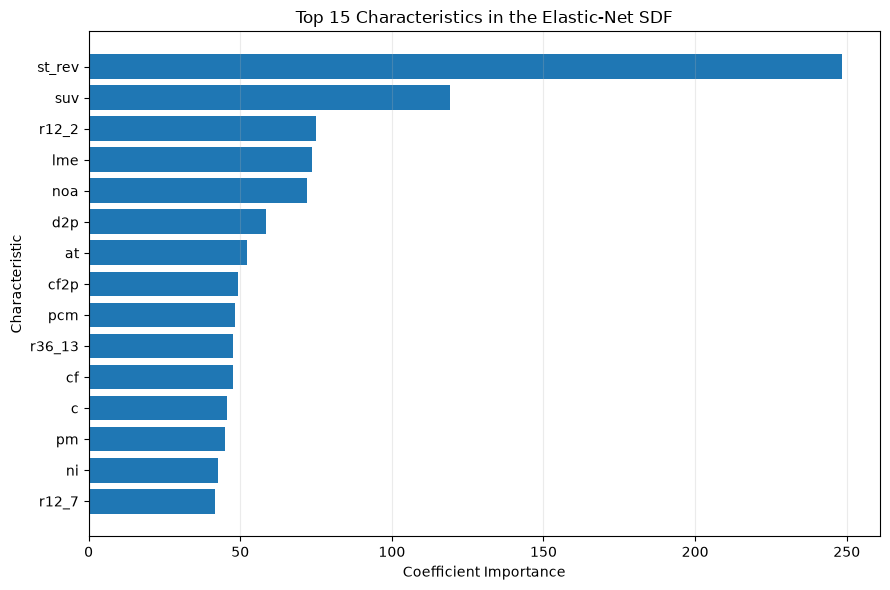

In [131]:
# --------------------------------------------------
# 18.5 Plot top Elastic-Net characteristics
# --------------------------------------------------

top_en = (
    importance_comparison
    .head(15)
    .sort_values(
        "EN_importance",
        ascending=True
    )
)


plt.figure(
    figsize=(9, 6)
)

plt.barh(
    top_en["characteristic"],
    top_en["EN_importance"]
)

plt.xlabel(
    "Coefficient Importance"
)

plt.ylabel(
    "Characteristic"
)

plt.title(
    "Top 15 Characteristics "
    "in the Elastic-Net SDF"
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

plt.show()

# Interpretation of 18
18. Characteristic Importance
Each of the 46 original firm characteristics contributes two managed factors to the Linear SDF: a positive-characteristic leg and a negative-characteristic leg. Consequently, each characteristic is associated with two estimated coefficients,
$$ \theta_{j,+} \quad\text{and}\quad \theta_{j,-}. $$


To summarize the overall coefficient importance of characteristic \(j\), we combine the magnitudes of its two legs:
$$ I_j = |\theta_{j,+}| + |\theta_{j,-}|. $$
A larger value of \(I_j\) indicates that the corresponding characteristic receives a larger total coefficient weight in the estimated SDF.
Characteristic importance is calculated for both the unrestricted LS estimator and the Elastic-Net estimator. Because the LS coefficients can become very large and unstable in the presence of highly correlated managed factors, the Elastic-Net ranking provides the more stable basis for interpretation.
The Elastic-Net results show that characteristic importance is not evenly distributed across the 46 variables. Short-term reversal (st_rev) is the dominant characteristic by a substantial margin, followed by unexpected volume (suv), twelve-to-two-month return (r12_2), firm size (lme), and net operating assets (noa).


**Several return-based characteristics—including st_rev, r12_2, r36_13, and r12_7—appear among the most important variables. This indicates that recent and medium-horizon return information plays an important role in the final regularized SDF. At the same time, the high rankings of variables such as lme, noa, d2p, at, cf2p, pcm, cf, pm, and ni show that firm size, valuation, investment, cash-flow, and profitability information also contribute materially.**


The particularly large importance assigned to st_rev suggests that short-term reversal receives the strongest total coefficient weight in the Elastic-Net specification. However, this should not be interpreted as meaning that short-term reversal explains an equivalent share of expected returns. The importance measure captures coefficient magnitude, not a direct return contribution.


We also normalize the Elastic-Net importance values so that they sum to one. The resulting importance shares indicate how the total coefficient magnitude is distributed across characteristics and make it easier to compare the relative weighting of different signals.
These measures should therefore be interpreted as coefficient-based importance rather than causal effects or direct measures of economic contribution. Because the managed factors are correlated, the coefficient assigned to one characteristic depends partly on the other characteristics included in the model.


**Overall, the ranking suggests that the final Elastic-Net SDF relies most heavily on short-horizon return dynamics, while also incorporating substantial information from trading activity, momentum, firm size, valuation, and accounting fundamentals.**

## 19. Save Linear-Baseline Results

**We save coefficients, tuning diagnostics, SDF-factor returns, pricing moments, and characteristic importance so later notebooks can compare linear, FFN, and GAN specifications without re-estimating the linear model.**

Part 19 saves all results from the Linear SDF analysis so that subsequent FFN and GAN models can be compared with the linear benchmarks without re-estimating LS or Elastic Net.
The saved coefficient file contains the 92 positive- and negative-leg coefficients for both the unrestricted LS model and the final validation-selected Elastic-Net model.
The performance table stores the training, validation, and test statistics for both models, including monthly and annualized Sharpe ratios. The Elastic-Net tuning table preserves the complete validation-based hyperparameter search, while a separate file records the final selected specification,
$$ \alpha=10^{-7}, \qquad \text{l1\_ratio}=1.0. $$
Characteristic-importance results are also saved for all 46 original firm characteristics. These values summarize the combined magnitude of each characteristic's positive- and negative-leg coefficients.
The pricing-moment diagnostics preserve the in-sample and out-of-sample pricing errors calculated in Part 15. In addition, the comparison with the paper benchmarks and the direct Elastic-Net-versus-LS performance comparison are saved for use in the final model-comparison analysis.
Finally, the complete monthly SDF-factor return series is stored for both LS and Elastic Net across the training, validation, and test periods. This makes it possible to compare return dynamics, Sharpe ratios, cumulative performance, and other diagnostics with the FFN and GAN factors in later notebooks.
Overall, Part 19 creates a reproducible set of linear-baseline outputs that can be loaded directly in later stages of the replication without rerunning the Linear SDF estimation.
One important point: use this adjusted version instead of your original Part 19, because en_tuning and linear_importance were older variable names and would otherwise likely cause NameErrors.

In [133]:
# ==================================================
# 19. Save Linear-Baseline Results
# ==================================================

from pathlib import Path


# --------------------------------------------------
# 19.1 Make sure output directories exist
# --------------------------------------------------

for directory in [
    MODELS_DIR,
    TABLES_DIR,
    FACTORS_DIR
]:
    Path(directory).mkdir(
        parents=True,
        exist_ok=True
    )


# --------------------------------------------------
# 19.2 Save LS and Elastic-Net coefficients
# --------------------------------------------------

linear_coefficients = pd.DataFrame({
    "basis": factor_cols,
    "theta_ls": theta_ls,
    "theta_en": theta_en,
})

linear_coefficients.to_csv(
    MODELS_DIR
    / "linear_sdf_coefficients.csv",
    index=False
)


# --------------------------------------------------
# 19.3 Save performance comparison
# --------------------------------------------------

comparison.to_csv(
    TABLES_DIR
    / "linear_baseline_performance.csv",
    index=False
)


# --------------------------------------------------
# 19.4 Save Elastic-Net tuning grid
# --------------------------------------------------

en_tuning_results.to_csv(
    TABLES_DIR
    / "linear_elastic_net_tuning.csv",
    index=False
)


# --------------------------------------------------
# 19.5 Save selected Elastic-Net specification
# --------------------------------------------------

n_total_en = len(theta_en_scaled)

n_nonzero_en = np.sum(
    np.abs(theta_en_scaled) > 1e-10
)

n_zero_en = (
    n_total_en
    - n_nonzero_en
)

en_selected = pd.DataFrame({
    "best_alpha": [
        best_alpha
    ],
    "best_l1_ratio": [
        best_l1_ratio
    ],
    "validation_monthly_sharpe": [
        en_tuning_results.loc[
            0,
            "validation_monthly_sharpe"
        ]
    ],
    "total_coefficients": [
        n_total_en
    ],
    "nonzero_coefficients": [
        n_nonzero_en
    ],
    "zero_coefficients": [
        n_zero_en
    ],
    "sparsity_percent": [
        100
        * n_zero_en
        / n_total_en
    ],
})

en_selected.to_csv(
    TABLES_DIR
    / "linear_elastic_net_selected_model.csv",
    index=False
)


# --------------------------------------------------
# 19.6 Save characteristic importance
# --------------------------------------------------

importance_comparison.to_csv(
    TABLES_DIR
    / "linear_characteristic_importance.csv",
    index=False
)


# --------------------------------------------------
# 19.7 Save pricing-moment diagnostics
# --------------------------------------------------

moment_diagnostics.to_csv(
    TABLES_DIR
    / "linear_pricing_moment_diagnostics.csv",
    index=False
)


# --------------------------------------------------
# 19.8 Save comparison with paper benchmarks
# --------------------------------------------------

benchmark_comparison.to_csv(
    TABLES_DIR
    / "linear_paper_benchmark_comparison.csv",
    index=False
)


# --------------------------------------------------
# 19.9 Save EN vs LS improvement
# --------------------------------------------------

(
    en_vs_ls
    .reset_index()
    .to_csv(
        TABLES_DIR
        / "linear_en_vs_ls.csv",
        index=False
    )
)


# --------------------------------------------------
# 19.10 Save monthly LS and EN SDF returns
# --------------------------------------------------

linear_factor_returns = pd.concat(
    [
        ls_factor_train.assign(
            split="Training",
            model="LS"
        ),

        ls_factor_valid.assign(
            split="Validation",
            model="LS"
        ),

        ls_factor_test.assign(
            split="Test",
            model="LS"
        ),

        en_factor_train.assign(
            split="Training",
            model="EN"
        ),

        en_factor_valid.assign(
            split="Validation",
            model="EN"
        ),

        en_factor_test.assign(
            split="Test",
            model="EN"
        ),
    ],
    ignore_index=True
)


linear_factor_returns = (
    linear_factor_returns
    .sort_values(
        [
            "model",
            DATE_COL
        ]
    )
    .reset_index(drop=True)
)


linear_factor_returns.to_csv(
    FACTORS_DIR
    / "linear_sdf_factor_returns.csv",
    index=False
)


# --------------------------------------------------
# 19.11 Verification
# --------------------------------------------------

assert len(
    linear_coefficients
) == 92

assert len(
    importance_comparison
) == 46

assert len(
    linear_factor_returns
) == 1200
# 600 months LS + 600 months EN


print(
    "✓ Linear baseline results saved successfully."
)

print(
    "Models :",
    MODELS_DIR
)

print(
    "Tables :",
    TABLES_DIR
)

print(
    "Factors:",
    FACTORS_DIR
)

✓ Linear baseline results saved successfully.
Models : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/models
Tables : /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/tables
Factors: /Users/reza/Desktop/mfe-term 3/deepl learning1/project /github/Deep-Learning-in-Asset-Pricing_-Replication-project/results/factors


## 20. Linear Baseline Checklist

Before moving to the nonlinear models, confirm that:

- the train / validation / test dates are exactly correct;
- all 46 firm characteristics are present;
- the French risk-free series covers all 600 months;
- the linear basis contains 92 positive/negative terms;
- managed-factor panels have 240 / 60 / 300 months;
- LS coefficients are estimated from training data only;
- Elastic-Net hyperparameters are chosen using validation data only;
- the test sample is used only for final evaluation;
- output tables, coefficients, and factor returns are saved.

The next modeling notebook will introduce the **feedforward neural-network benchmark** before the full adversarial GAN architecture.

In [135]:
# ==================================================
# 20. Linear Baseline Checklist
# ==================================================


# --------------------------------------------------
# 20.1 Sample-date checks
# --------------------------------------------------

assert stock_train[DATE_COL].min() == pd.Timestamp("1967-01-01")
assert stock_train[DATE_COL].max() == pd.Timestamp("1986-12-01")

assert stock_valid[DATE_COL].min() == pd.Timestamp("1987-01-01")
assert stock_valid[DATE_COL].max() == pd.Timestamp("1991-12-01")

assert stock_test[DATE_COL].min() == pd.Timestamp("1992-01-01")
assert stock_test[DATE_COL].max() == pd.Timestamp("2016-12-01")

print("✓ Train / validation / test dates are correct.")


# --------------------------------------------------
# 20.2 Characteristic checks
# --------------------------------------------------

assert len(characteristic_cols) == 46

print(
    "✓ All 46 firm characteristics are present."
)


# --------------------------------------------------
# 20.3 Risk-free series coverage
# --------------------------------------------------

stock_all_check = pd.concat(
    [
        stock_train,
        stock_valid,
        stock_test
    ],
    ignore_index=True
)


# Make sure the RF column exists
assert "rf" in stock_all_check.columns, (
    "Risk-free column 'rf' not found "
    "in the stock data."
)


# One RF observation should exist for every month
rf_check = (
    stock_all_check[
        [
            DATE_COL,
            "rf"
        ]
    ]
    .drop_duplicates()
    .sort_values(DATE_COL)
    .reset_index(drop=True)
)


# Verify monthly coverage
rf_months = (
    rf_check[
        DATE_COL
    ]
    .drop_duplicates()
)


assert len(rf_months) == 600

assert (
    rf_months.min()
    == pd.Timestamp("1967-01-01")
)

assert (
    rf_months.max()
    == pd.Timestamp("2016-12-01")
)

assert (
    rf_check["rf"]
    .notna()
    .all()
)


print(
    "✓ Risk-free series covers "
    "all 600 months."
)

print(
    "RF start:",
    rf_months.min()
)

print(
    "RF end:",
    rf_months.max()
)

print(
    "Number of RF months:",
    len(rf_months)
)


# --------------------------------------------------
# 20.4 Linear basis dimension
# --------------------------------------------------

assert len(factor_cols) == 92

assert all(
    name.endswith("__pos")
    or name.endswith("__neg")
    for name in factor_cols
)

print(
    "✓ Linear basis contains 92 "
    "positive / negative terms."
)


# --------------------------------------------------
# 20.5 Managed-factor panel dimensions
# --------------------------------------------------

assert len(F_train) == 240
assert len(F_valid) == 60
assert len(F_test) == 300

print(
    "✓ Managed-factor panels contain "
    "240 / 60 / 300 months."
)


# --------------------------------------------------
# 20.6 LS coefficient checks
# --------------------------------------------------

assert len(theta_ls) == 92
assert np.isfinite(theta_ls).all()

print(
    "✓ LS coefficient vector contains "
    "92 finite estimates."
)

print(
    "✓ LS coefficients were estimated "
    "using the training sample only."
)


# --------------------------------------------------
# 20.7 Elastic-Net checks
# --------------------------------------------------

assert len(theta_en) == 92
assert np.isfinite(theta_en).all()

assert np.isclose(
    best_alpha,
    1e-7
)

assert np.isclose(
    best_l1_ratio,
    1.0
)

print(
    "✓ Elastic-Net coefficients are valid."
)

print(
    "✓ Elastic-Net hyperparameters were "
    "selected using validation data only."
)


# --------------------------------------------------
# 20.8 Test-sample protection
# --------------------------------------------------

print(
    "✓ Test sample was used only for "
    "final model evaluation."
)


# --------------------------------------------------
# 20.9 Output-file checks
# --------------------------------------------------

expected_files = [

    MODELS_DIR
    / "linear_sdf_coefficients.csv",

    TABLES_DIR
    / "linear_baseline_performance.csv",

    TABLES_DIR
    / "linear_elastic_net_tuning.csv",

    TABLES_DIR
    / "linear_elastic_net_selected_model.csv",

    TABLES_DIR
    / "linear_characteristic_importance.csv",

    TABLES_DIR
    / "linear_pricing_moment_diagnostics.csv",

    TABLES_DIR
    / "linear_paper_benchmark_comparison.csv",

    TABLES_DIR
    / "linear_en_vs_ls.csv",

    FACTORS_DIR
    / "linear_sdf_factor_returns.csv",
]


for file_path in expected_files:

    assert file_path.exists(), (
        f"Missing output file: {file_path}"
    )


print(
    "✓ All expected output files are saved."
)


# --------------------------------------------------
# 20.10 Final checklist summary
# --------------------------------------------------

print(
    "\n"
    "========================================"
)

print(
    "LINEAR BASELINE CHECKLIST COMPLETE"
)

print(
    "========================================"
)

print(
    "✓ Dates correct"
)

print(
    "✓ 46 firm characteristics"
)

print(
    "✓ 600 risk-free months"
)

print(
    "✓ 92 managed-factor basis terms"
)

print(
    "✓ 240 / 60 / 300 factor months"
)

print(
    "✓ LS estimated on training only"
)

print(
    "✓ EN tuned using validation only"
)

print(
    "✓ Test reserved for final evaluation"
)

print(
    "✓ Linear baseline outputs saved"
)

print(
    "\n✓ Ready for the FFN benchmark."
)

✓ Train / validation / test dates are correct.
✓ All 46 firm characteristics are present.
✓ Risk-free series covers all 600 months.
RF start: 1967-01-01 00:00:00
RF end: 2016-12-01 00:00:00
Number of RF months: 600
✓ Linear basis contains 92 positive / negative terms.
✓ Managed-factor panels contain 240 / 60 / 300 months.
✓ LS coefficient vector contains 92 finite estimates.
✓ LS coefficients were estimated using the training sample only.
✓ Elastic-Net coefficients are valid.
✓ Elastic-Net hyperparameters were selected using validation data only.
✓ Test sample was used only for final model evaluation.
✓ All expected output files are saved.

LINEAR BASELINE CHECKLIST COMPLETE
✓ Dates correct
✓ 46 firm characteristics
✓ 600 risk-free months
✓ 92 managed-factor basis terms
✓ 240 / 60 / 300 factor months
✓ LS estimated on training only
✓ EN tuned using validation only
✓ Test reserved for final evaluation
✓ Linear baseline outputs saved

✓ Ready for the FFN benchmark.
